#  Generative AI Model (VAE) to Predict Gene Expression from Drug SMILES

### Project Introduction

This project tackles a core challenge in drug discovery: predicting how a drug will affect a cell's biology before it's ever tested in the lab. 
```
Gene Expression Change = f(Drug, Cell Type)
```
We use the LINCS L1000 (GSE92742) dataset, because it is the gold-standard, largest, and most comprehensive public resource designed for exactly this project's goal: predicting how a cell's gene expression changes in response to a drug. The dataset contains each variable in the equation above:

  * **Gene Expression Change**: It contains the gene expression changes (the Z-scores in the .gctx file).

  * **Drug**: It tells you which drug was used for each experiment (in the sig_info and pert_info files).

  * **Cell Type**: It tells you which cell type was used (also in the sig_info file)

We build a deep generative model to address this challenge by learning how different drugs change gene expression.  Mapping the post-treatment gene expression to a compact latent space using a Variational Autoencoder, the model can ifer a gene expression profile from a novel drug that it has never seen before.

The steps carried out in this notebook include:

  1. **Exploratory Data Analysis (EDA)**: ...
  
  

--- 
### References

**Data Sources and Platforms**

* [LINCS L1000 (GSE92742)](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742): The data used here is the LINCS L1000 - the gold-standard, largest and most comprehensive public resource designed for predicting how a cell's gene expression changes in response to a drug.

**Libraries**
* [RDKit](https://www.rdkit.org/docs/#)
* [GSEAPY](https://gseapy.readthedocs.io/en/latest/introduction.html)

---
### Table of Contents

1. [Imports](#imports)
2. [Utility Functions](#utility-functions)
3. [Constants & Data Import](#constants-&-data-import)
4. [Data Exploration](#data-exploration)
5. [Data Pre-processing](#data-pre-processing)
6. [Build the Model](#build-the-model) 
7. [Clustering & Visualization](#clustering-&-visualization)
8. [Summary](#summary)

---
### 1. Imports <a class="anchor" id="imports"></a>

In [1]:
import os
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
from cmapPy.pandasGEXpress.parse import parse as parse_gctx
import gseapy

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from typing import Any
from tqdm import tqdm

import wandb
import yaml


---
### 2. Constants & Data Import <a class="anchor" id="constants"></a>


The necessary data files can be accessed and downloaded via the [Gene Expression Omnibus Portal](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742). The following specific datasets are required:

* **The Gene Expression Data**

    *GSE92742_Broad_LINCS_Level5_COMPZ.MODZ_n473647x12328.gctx.gz* 
    
    The main data matrix that contains the results of nearly half a million experiments (how much a gene's expression went up or down in a single experiment compared to a control)

* **The Signature Info File**

    *GSE92742_Broad_LINCS_sig_info.txt*

    Metadata file that explains what each column in the expression matrix means.

* **The Perturbation Info File**

    *GSE92742_Broad_LINCS_pert_info.txt*

    The drug dictionary that provides details about the perturbations used in the experiments.

* **The Gene Info File**

    *GSE92742_Broad_LINCS_gene_info.txt*

    The gene dictionary that provides details about the genes measured.


The notebook expects both tsv files to be placed in the `data/LINCS_L1000` folder.

In [2]:
ROOT = Path(os.getcwd()).parents[0]

DATA_PATH = os.path.join(ROOT, "data", "LINCS_L1000")
GCTX_DATA_PATH = os.path.join(
    DATA_PATH, "GSE92742_Broad_LINCS_Level5_COMPZ.MODZ_n473647x12328.gctx"
)

GENE_INFO_PATH = os.path.join(DATA_PATH, "GSE92742_Broad_LINCS_gene_info.txt")
PERTURBATION_DATA_PATH = os.path.join(DATA_PATH, "GSE92742_Broad_LINCS_pert_info.txt")
SIGNATURE_DATA_PATH = os.path.join(DATA_PATH, "GSE92742_Broad_LINCS_sig_info.txt")
MOA_DATA_PATH = os.path.join(DATA_PATH, "repurposing_drugs_20180907.txt")

---
### 3. Utility Functions <a class="anchor" id="utility"></a>

#### Data Loader

In [3]:
class LincsDataset(Dataset):
    """Dataset for LINCS drug-induced gene expression prediction."""

    def __init__(self, df_expression: pd.DataFrame, df_meta: pd.DataFrame):
        """
        Args:
            df_expression (pd.DataFrame): DataFrame containing gene expression data with genes as columns and samples pert_ids as rows.
            fingerprint_map (Dict[str, np.ndarray]): Dictionary mapping perturbation IDs to their corresponding fingerprints.
        """
        self.df_expression = df_expression
        self.df_meta = df_meta
        # Ensure that the perturbation IDs in the expression data match those in the metadata
        self.pert_ids = df_expression.index.intersection(self.df_meta.index).tolist()

        self.df_expression = df_expression.loc[self.pert_ids]
        self.df_meta = df_meta.loc[self.pert_ids]

    def __len__(self):
        """Returns the number of samples in the dataset."""
        return len(self.df_expression)

    def __getitem__(self, idx: int) -> Tuple[np.ndarray, np.ndarray]:
        """Returns the fingerprint and gene expression values for a given index.
        Args:
            idx (int): Index of the sample to retrieve.
        Returns:
            Tuple[np.ndarray, np.ndarray]: A tuple containing the fingerprint and the gene expression values.
        """
        if idx < 0 or idx >= len(self):
            raise IndexError("Index out of bounds for dataset.")

        pert_id = self.pert_ids[idx]
        if pert_id not in self.df_meta.index:
            raise KeyError(f"Perturbation ID {pert_id} not found in metadata.")

        # Convert to PyTorch tensors
        expression_tensor = torch.tensor(
            self.df_expression.loc[pert_id].values, dtype=torch.float
        )
        fingerprint_tensor = torch.tensor(
            self.df_meta.loc[pert_id, "fingerprint"], dtype=torch.float
        )
        moa_label_tensor = torch.tensor(
            self.df_meta.loc[pert_id, "moa_int"], dtype=torch.int64
        )

        return fingerprint_tensor, expression_tensor, moa_label_tensor

    def get_item_by_pert_id(self, pert_id: str) -> Tuple[np.ndarray, np.ndarray]:
        """Returns the fingerprint and gene expression values for a given perturbation ID.
        Args:
            pert_id (str): Perturbation ID to retrieve.
        Returns:
            Tuple[np.ndarray, np.ndarray]: A tuple containing the fingerprint and the gene expression values.
        """
        if pert_id not in self.df_meta.index:
            raise KeyError(f"Perturbation ID {pert_id} not found in metadata.")

        expression_tensor = torch.tensor(
            self.df_expression.loc[pert_id].values, dtype=torch.float
        )
        fingerprint_tensor = torch.tensor(
            self.df_meta.loc[pert_id, "fingerprint"], dtype=torch.float
        )
        moa_label_tensor = torch.tensor(
            self.df_meta.loc[pert_id, "moa_int"], dtype=torch.int64
        )

        return fingerprint_tensor, expression_tensor, moa_label_tensor

#### Model Architecture

**Encoder**

This module takes the gene expression data and the embedded chemical fingerprint as input and compresses them into a lower-dimensional latent space. It doesn't output a single point, but rather the parameters—mean (mu) and log-variance (logvar)—of a probability distribution.

In [4]:
class Encoder(torch.nn.Module):
    """Encoder for the Conditional Variational Autoencoder (CVAE).

    Encodes input data into latent space parameters (mean and log-variance).
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        latent_dim: int,
        num_layers: int = 0,
        dropout_rate: float = 0.2,
    ) -> None:
        """
        Args:
            input_dim (int): Dimension of the input data.
            hidden_dim (int): Dimension of the hidden layer.
            latent_dim (int): Dimension of the latent space.
            num_layers (int, optional): Number of hidden layers. Defaults to 0.
            dropout_rate (float, optional): Dropout rate. Defaults to 0.2.
        """
        super(Encoder, self).__init__()

        self.fc_initial = nn.Linear(input_dim, hidden_dim * (num_layers + 1))

        self.fc_layers = nn.ModuleList()
        if num_layers > 0:
            for layer_mult in range(1, num_layers + 1)[::-1]:
                self.fc_layers.append(
                    nn.Linear(hidden_dim * (layer_mult + 1), hidden_dim * layer_mult)
                )

        self.dropout = nn.Dropout(p=dropout_rate)

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass through the encoder.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            Tuple[torch.Tensor, torch.Tensor]: Mean and log-variance tensors.
        """
        x = torch.relu(self.fc_initial(x))
        x = self.dropout(x)

        for fc_layer in self.fc_layers:
            x = torch.relu(fc_layer(x))
            x = self.dropout(x)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar


**Decoder**

This module performs the reverse operation. It takes a sample (z) from the latent space and the embedded chemical fingerprint and decompresses them, attempting to reconstruct the original gene expression data.

In [5]:
class Decoder(torch.nn.Module):
    """Decoder for the Conditional Variational Autoencoder (CVAE).

    Decodes latent variables and condition embeddings to reconstruct input data.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        num_layers: int = 0,
        dropout_rate: float = 0.2,
    ) -> None:
        """
        Args:
            input_dim (int): Dimension of the input latent vector.
            hidden_dim (int): Dimension of the hidden layer.
            output_dim (int): Dimension of the output data.
            num_layers (int, optional): Number of hidden layers. Defaults to 0.
            dropout_rate (float, optional): Dropout rate. Defaults to 0.2.
        """
        super(Decoder, self).__init__()

        self.dropout = nn.Dropout(p=dropout_rate)

        self.fc_initial = nn.Linear(input_dim, hidden_dim * 8)

        self.fc_layers = nn.ModuleList()
        if num_layers > 0:
            for layer_mult in range(1, num_layers + 1):
                self.fc_layers.append(
                    nn.Sequential(
                        nn.Linear(hidden_dim * layer_mult * 8, hidden_dim * (layer_mult + 1) * 8),
                        nn.BatchNorm1d(hidden_dim * (layer_mult + 1) * 8),
                        nn.ReLU(),
                        nn.Dropout(p=dropout_rate)
                    )
                )

        self.fc_final = nn.Linear(hidden_dim * (num_layers + 1) * 8, output_dim)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the decoder.

        Args:
            z (torch.Tensor): Latent variable concatenated with condition embedding.

        Returns:
            torch.Tensor: Reconstructed input tensor.
        """
        x = torch.relu(self.fc_initial(z))
        x = self.dropout(x)

        for fc_layer in self.fc_layers:
            x = fc_layer(x)

        x_reconstructed = self.fc_final(x)

        return x_reconstructed


**Classification Head**

This is a simple classifier that takes the stable representation of the data from the latent space (mu) and tries to predict a class label, such as the drug's Mechanism of Action (MoA) (the "supervised" part of the model).

In [6]:
class ClassificationHead(torch.nn.Module):
    """Classification head for the Conditional Variational Autoencoder (CVAE).

    Maps latent variables to class logits.
    """

    def __init__(
        self,
        latent_dim: int,
        output_dim: int,
        dropout_rate: float = 0.3,
    ) -> None:
        """
        Args:
            latent_dim (int): Dimension of the latent space.
            output_dim (int): Number of output classes.
            dropout_rate (float, optional): Dropout rate. Defaults to 0.3.
        """
        super(ClassificationHead, self).__init__()

        self.fc_initial = nn.Linear(latent_dim, output_dim)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, mu: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the classification head.

        Args:
            mu (torch.Tensor): Latent mean tensor.

        Returns:
            torch.Tensor: Logits for classification.
        """
        logits = self.fc_initial(mu)
        return logits


**Molecular Embedding Module**

This is a dedicated sub-network whose only job is to take the large, raw chemical fingerprint (e.g., 2048 bits) and compress it into a smaller, dense feature vector. This creates a more meaningful representation of the compound before it's used by the encoder and decoder.

In [7]:
class MolecularEmbedding(torch.nn.Module):
    """Molecular embedding layer for the Conditional Variational Autoencoder (CVAE).

    Embeds condition (e.g., molecular fingerprint) data.
    """

    def __init__(
        self,
        condition_dim: int = 2048,
        condition_emb_dim: int = 64,
        num_layers: int = 0,
        dropout_rate: float = 0.2,
    ) -> None:
        """
        Args:
            condition_dim (int, optional): Dimension of the condition data. Defaults to 2048.
            condition_emb_dim (int, optional): Dimension of the embedded condition data. Defaults to 64.
            num_layers (int, optional): Number of hidden layers. Defaults to 0.
            dropout_rate (float, optional): Dropout rate. Defaults to 0.2.
        """
        super(MolecularEmbedding, self).__init__()
        self.fc_initial = nn.Linear(condition_dim, condition_emb_dim * (num_layers + 1))

        self.fc_layers = nn.ModuleList()
        if num_layers > 0:
            for layer_mult in range(1, num_layers + 1)[::-1]:
                self.fc_layers.append(
                    nn.Linear(
                        condition_emb_dim * (layer_mult + 1),
                        condition_emb_dim * layer_mult,
                    )
                )

        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, c: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the molecular embedding layer.

        Args:
            c (torch.Tensor): Condition (fingerprint) tensor.

        Returns:
            torch.Tensor: Embedded condition tensor.
        """
        c = torch.relu(self.fc_initial(c))
        for fc_layer in self.fc_layers:
            c = torch.relu(fc_layer(c))
            c = self.dropout(c)
        return c


**Conditional Variational Autoencoder**

This is the main, top-level module that assembles all the other pieces. It orchestrates the end-to-end flow of data: embedding the fingerprint, passing data through the encoder to get the latent parameters, sampling from the latent space, and passing the result through the decoder to get the final reconstruction. It also contains the ClassificationHead for the semi-supervised task.

In [8]:
class CVAE(torch.nn.Module):
    """Conditional Variational Autoencoder for drug-induced gene expression prediction.

    Combines encoder, decoder, molecular embedding, and classification head.
    """

    def __init__(
        self,
        expression_dim: int,
        num_classes: int,
        num_encoder_layers: int = 0,
        encoder_dropout_rate: float = 0.2,
        num_decoder_layers: int = 0,
        decoder_dropout_rate: float = 0.2,
        condition_dim: int = 2048,
        condition_emb_dim: int = 64,
        hidden_dim: int = 512,
        latent_dim: int = 128,
        num_molecular_emb_layers: int = 0,
    ) -> None:
        """
        Args:
            expression_dim (int): Dimension of the gene expression data.
            num_classes (int): Number of output classes.
            num_encoder_layers (int, optional): Number of encoder layers. Defaults to 0.
            encoder_dropout_rate (float, optional): Encoder dropout rate. Defaults to 0.2.
            num_decoder_layers (int, optional): Number of decoder layers. Defaults to 0.
            decoder_dropout_rate (float, optional): Decoder dropout rate. Defaults to 0.2.
            condition_dim (int, optional): Dimension of the condition data. Defaults to 2048.
            condition_emb_dim (int, optional): Dimension of the embedded condition data. Defaults to 64.
            hidden_dim (int, optional): Hidden dimension for encoder/decoder. Defaults to 512.
            latent_dim (int, optional): Dimension of the latent space. Defaults to 128.
            num_molecular_emb_layers (int, optional): Number of molecular embedding layers. Defaults to 0.
        """
        super(CVAE, self).__init__()
        self.expression_dim = expression_dim
        self.condition_dim = condition_dim
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim

        self.molecular_embedding = MolecularEmbedding(
            condition_dim=condition_dim,
            condition_emb_dim=condition_emb_dim,
            num_layers=num_molecular_emb_layers,
        )

        self.classification_head = ClassificationHead(
            latent_dim=latent_dim,
            output_dim=num_classes,
        )

        self.encoder = Encoder(
            input_dim=self.expression_dim + condition_emb_dim,
            hidden_dim=self.hidden_dim,
            latent_dim=self.latent_dim,
            num_layers=num_encoder_layers,
            dropout_rate=encoder_dropout_rate,
        )

        self.decoder = Decoder(
            input_dim=self.latent_dim + condition_emb_dim,
            hidden_dim=self.hidden_dim,
            output_dim=self.expression_dim,
            num_layers=num_decoder_layers,
            dropout_rate=decoder_dropout_rate,
        )

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        """
        Reparameterization trick for sampling from latent space.

        Args:
            mu (torch.Tensor): Mean tensor.
            log_var (torch.Tensor): Log-variance tensor.

        Returns:
            torch.Tensor: Sampled latent variable.
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def classify(self, mu: torch.Tensor) -> torch.Tensor:
        """
        Classify the latent variable using the classification head.

        Args:
            mu (torch.Tensor): Latent mean tensor.

        Returns:
            torch.Tensor: Logits for classification.
        """
        logits = self.classification_head(mu)
        return logits

    def forward(
        self, x: torch.Tensor, c: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Forward pass through the CVAE.

        Args:
            x (torch.Tensor): Input gene expression tensor.
            c (torch.Tensor): Condition (fingerprint) tensor.

        Returns:
            Tuple[torch.Tensor, torch.Tensor, torch.Tensor]: Reconstructed input, mean, and log-variance tensors.
        """
        c_embs = self.molecular_embedding(c)
        x = torch.cat((x, c_embs), dim=1)
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        z = torch.cat((z, c_embs), dim=1)
        x_reconstructed = self.decoder(z)
        return x_reconstructed, mu, logvar


#### Loss Function

In [9]:
def vae_loss_function(
    recon_x: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    log_var: torch.Tensor,
    latent_dim: int,
    beta: float = 1.0,
    recon_weight: float = 1000,
    free_bits_per_dim: float = 0.02,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Computes the loss function for a Variational Autoencoder (VAE), combining reconstruction loss and KL divergence.

    Args:
        recon_x (torch.Tensor): The reconstructed output from the decoder.
        x (torch.Tensor): The original input data.
        mu (torch.Tensor): The mean of the latent Gaussian distribution.
        log_var (torch.Tensor): The log variance of the latent Gaussian distribution.
        latent_dim (int): The dimensionality of the latent space.
        beta (float, optional): Weight for the KL divergence term. Default is 1.0.
        recon_weight (float, optional): Weight for the reconstruction loss term. Default is 1000.
        free_bits_per_dim (float, optional): Minimum KL divergence per latent dimension before penalizing (free bits). Default is 0.02.

    Returns:
        tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
            - Total VAE loss (torch.Tensor)
            - Reconstruction loss (torch.Tensor)
            - KL divergence (torch.Tensor)
    """
    # Reconstruction Loss
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction="mean")

    # KL Divergence
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # Normalize KL divergence by batch size
    kl_div /= x.size(0)

    # Target 0.02 bits of information per latent dimension before penalizing
    kl_div = torch.clamp(kl_div, min=free_bits_per_dim * latent_dim)

    return recon_loss * recon_weight + beta * kl_div, recon_loss, kl_div

#### Evaluation Functions

In [10]:
def get_control_and_test_profiles(pert_id_to_test, pert_id_control, dataset, df_gene, model, device):
    """
    Get the control and test profiles for a given perturbation ID.

    Args:
        pert_id_to_test (str): The perturbation ID to test.
        dataset (LincsDataset): The dataset containing the profiles.
        pert_id_control (str, optional): The control perturbation ID. Defaults to "DMSO".

    Returns:
        tuple: Condition and expression tensors for the test and control profiles.
    """

    condition_x, expression_x, _ = dataset.get_item_by_pert_id(pert_id_to_test)
    _, expression_dmso, _ = dataset.get_item_by_pert_id(
        pert_id_control
    )

    control_profile = dataset.df_expression.mean()

    all_gene_names = control_profile.index.tolist()
    all_gene_names = (
        df_gene[["pr_gene_id", "pr_gene_symbol"]]
        .set_index("pr_gene_id")
        .loc[control_profile.index.astype(int)]
        .values.squeeze()
        .tolist()
    )
    control_x = control_profile.values
    # control_x = expression_dmso.squeeze().detach().cpu().numpy()
    

    condition_x = condition_x.unsqueeze(0).to(device)
    expression_x = expression_x.unsqueeze(0).to(device)

    recon_x, _, _ = model(expression_x, condition_x)

    return expression_x, condition_x, recon_x, control_x, all_gene_names


def get_monte_carlo_generation(condition_x, model, device, num_samples=1000):
    all_generated_profiles = []
    for i in range(num_samples):
        torch.manual_seed(i)
        # Generate a new random latent vector
        z = torch.randn(condition_x.shape[0], model.latent_dim).to(device)
        c_embs = model.molecular_embedding(condition_x)

        z = torch.cat((z, c_embs), dim=1)

        generated_x = model.decoder(z)

        all_generated_profiles.append(generated_x.detach().cpu())
    
    mean_generated_x = torch.mean(torch.stack(all_generated_profiles), dim=0)

    return mean_generated_x


def calculate_log2_fold_change_from_control(recon_x, control_np, all_gene_names):
    """Calculate log2 fold change from the control profile.

    Args:
        recon_x (torch.Tensor): The reconstructed gene expression profile.
        control_np (np.ndarray): The control gene expression profile.
        all_gene_names (list): List of gene names corresponding to the expression profiles.
    """
    recon_x_np = recon_x.detach().cpu().numpy()
    log2_fold_change = recon_x_np - control_np

    ranked_gene_df = pd.DataFrame(
        {"gene_name": all_gene_names, "log2fc": log2_fold_change.squeeze()}
    )

    return ranked_gene_df.sort_values(by="log2fc", ascending=False)


def get_gsea_prerank(recon_x, control_np, all_gene_names):
    """Get the GSEA prerank DataFrame."""
    ranked_gene_df = calculate_log2_fold_change_from_control(
        recon_x, control_np, all_gene_names
    )
    prerank_obj = gseapy.prerank(
        rnk=ranked_gene_df, gene_sets="KEGG_2021_Human", seed=42
    )

    results_df = prerank_obj.res2d

    ranked_gene_df = ranked_gene_df.set_index("gene_name")
    significant_results = results_df[results_df["FDR q-val"] < 0.05]

    return significant_results


def evaluate_recon_and_gen_gsea_for_pert(pert_id_to_test, pert_id_control, val_dataset, df_gene, img_save_path, model, device):

    expression_x, condition_x, recon_x, control_x, all_gene_names = get_control_and_test_profiles(
        pert_id_to_test, pert_id_control, val_dataset, df_gene, model, device
    )

    mean_generated_x = get_monte_carlo_generation(condition_x, model, device)

    df_generated_results = get_gsea_prerank(mean_generated_x, control_x, all_gene_names)
    df_expression_results = get_gsea_prerank(expression_x, control_x, all_gene_names)
    df_reconstructed_results = get_gsea_prerank(recon_x, control_x, all_gene_names)

    df_results = pd.concat(
        [
            df_expression_results.set_index("Term")["ES"],
            df_reconstructed_results.set_index("Term")["ES"],
            df_generated_results.set_index("Term")["ES"],
        ],
        axis=1,
        keys=["Original Expression", "Reconstructed Expression", "Generated Expression"],
    )

    df_results = df_results.dropna(subset="Original Expression")
    df_results = df_results.fillna(0)

    gsea_recon_error = np.abs(df_results["Original Expression"] - df_results["Reconstructed Expression"]).sum().tolist()
    gsea_gen_error = np.abs(df_results["Original Expression"] - df_results["Generated Expression"]).sum().tolist()

    df_plot = pd.melt(
        df_results.dropna(subset="Original Expression").iloc[:10].reset_index(),
        id_vars=["Term"],
        var_name="Profile Type",
        value_name="Enrichment Score",
    )

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Create the bar plot
    ax = sns.barplot(
        data=df_plot,
        y="Term",
        x="Enrichment Score",
        hue="Profile Type",
        orient="h",
    )

    # Add a vertical line at zero for reference
    ax.axvline(0, color="black", lw=1)
    ax.grid(False)
    ax.set_title("GSEA Comparison for Bortezomib", fontsize=16)
    ax.set_xlabel("Normalized Enrichment Score (NES)", fontsize=12)
    ax.set_ylabel("")
    plt.legend(title="Profile Source")

    plt.savefig(os.path.join(img_save_path, "gsea_comparison.png"))

    return gsea_recon_error, gsea_gen_error


In [11]:
def get_recon_correlation(model, train_loader, val_loader, img_save_path):
    train_expression = []
    train_reconstruction = []
    for (condition, expression, moa_label) in train_loader:
        recon_x, mu, log_var = model(expression, condition)
        train_reconstruction.append(recon_x.detach().cpu().numpy())
        train_expression.append(expression.detach().cpu().numpy())

    train_expression = np.vstack(train_expression)
    train_reconstruction = np.vstack(train_reconstruction)

    val_expression = []
    val_reconstruction = []
    for (condition, expression, moa_label) in val_loader:
        recon_x, mu, log_var = model(expression, condition)
        val_reconstruction.append(recon_x.detach().cpu().numpy())
        val_expression.append(expression.detach().cpu().numpy())
    val_expression = np.vstack(val_expression)
    val_reconstruction = np.vstack(val_reconstruction)
    

    val_corr = np.corrcoef(val_reconstruction.flatten(), val_expression.flatten())
    train_corr = np.corrcoef(train_reconstruction.flatten(), train_expression.flatten())

    _, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
    axes[0].hist(
        train_reconstruction.flatten() - train_expression.flatten(),
        bins=np.linspace(-3, 3, 20),
        alpha=0.5,
        label="Training Data"
    )
    axes[1].hist(
        val_reconstruction.flatten() - val_expression.flatten(),
        bins=np.linspace(-3, 3, 20),
        alpha=0.5,
        label="Validation Data",
    )
    axes[0].set_title("Distribution of Reconstruction Residuals (Training Data)\nCorrelation: {:.2f}".format(train_corr[0, 1]))
    axes[1].set_title("Distribution of Reconstruction Residuals (Validation Data)\nCorrelation: {:.2f}".format(val_corr[0, 1]))
    axes[0].set_xlabel("Reconstructed Residuals")
    axes[0].set_ylabel("Frequency")
    axes[1].set_xlabel("Reconstructed Residuals")
    plt.tight_layout()

    plt.savefig(os.path.join(img_save_path, "residuals.png"))

    return train_corr[0, 1], val_corr[0, 1]


#### Training Functions

In [12]:
def training_loop(
    model: nn.Module,
    train_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    num_epochs: int,
    alpha: float,
    beta: float,
    gamma: float,
    device: torch.device,
    epoch: int,
) -> Tuple[nn.Module, float, float, float, float]:
    """
    Perform one epoch of training for the model.

    Args:
        model (nn.Module): The model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        optimizer (torch.optim.Optimizer): Optimizer for model parameters.
        num_epochs (int): Total number of epochs.
        alpha (float): Reconstruction loss weight.
        beta (float): KL divergence loss weight.
        gamma (float): Classification loss weight.
        device (torch.device): Device to run training on.
        epoch (int): Current epoch number.

    Returns:
        Tuple[nn.Module, float, float, float, float]:
            Updated model, total train loss, reconstruction loss, KL loss, classification loss.
    """
    train_loss, train_recon, train_kl, train_class_loss = 0, 0, 0, 0

    pbar_train = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")
    for condition, expression, moa_label in pbar_train:
        expression = expression.to(device)
        condition = condition.to(device)
        moa_label = moa_label.to(device)

        model.train()
        optimizer.zero_grad()

        # Forward pass
        recon_x, mu, log_var = model(expression, condition)
        moa_prediction = model.classify(mu)
        # mask for only those MOAs that are known
        mask = moa_label != -1
        epoch_class_loss = torch.tensor(0.0, device=device)
        if mask.sum() > 0:
            labeled_preds = moa_prediction[mask]
            labeled_labels = moa_label[mask]
            epoch_class_loss = nn.functional.cross_entropy(
                labeled_preds, labeled_labels
            )

        loss, recon, kl = vae_loss_function(
            recon_x, expression, mu, log_var, model.latent_dim, beta, recon_weight=alpha
        )

        # Add classification loss to the total loss
        loss += gamma * epoch_class_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        train_recon += recon.item()
        train_kl += kl.item()
        train_class_loss += epoch_class_loss.item()

        pbar_train.set_description(
            f"Epoch {epoch:02d} | "
            f"Total Train Loss: {train_loss / len(train_loader):.4f} | "
            f"Train Reconstruction Loss: {train_recon / len(train_loader):.4f} | "
            f"Train Classification Loss: {train_class_loss / len(train_loader):.4f} | "
            f"Train KL Divergence: {train_kl / len(train_loader):.4f} | "
            f"Beta: {beta:.4f} | "
            f"Gamma: {gamma:.4f}"
        )

    return model, train_loss, train_recon, train_kl, train_class_loss


def validation_loop(
    model: nn.Module,
    val_loader: DataLoader,
    device: torch.device,
    alpha: float,
    beta: float,
    epoch: int,
    num_epochs: int,
) -> Tuple[float, float, float, float]:
    """
    Perform one epoch of validation for the model.

    Args:
        model (nn.Module): The model to validate.
        val_loader (DataLoader): DataLoader for the validation dataset.
        device (torch.device): Device to run validation on.
        alpha (float): Reconstruction loss weight.
        beta (float): KL divergence loss weight.
        epoch (int): Current epoch number.
        num_epochs (int): Total number of epochs.

    Returns:
        Tuple[float, float, float, float]:
            Total validation loss, reconstruction loss, KL loss, classification loss.
    """
    model.eval()
    val_loss, val_recon, val_kl, val_class_loss = 0, 0, 0, 0

    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} Validation")
    with torch.no_grad():
        for condition, expression, moa_label in pbar_val:
            expression = expression.to(device)
            condition = condition.to(device)
            moa_label = moa_label.to(device)

            recon_x, mu, log_var = model(expression, condition)
            moa_prediction = model.classify(mu)

            loss, recon, kl = vae_loss_function(
                recon_x,
                expression,
                mu,
                log_var,
                model.latent_dim,
                beta,
                recon_weight=alpha,
            )

            mask = moa_label != -1
            epoch_class_loss = 0
            if mask.sum() > 0:
                labeled_preds = moa_prediction[mask]
                labeled_labels = moa_label[mask]
                epoch_class_loss = nn.functional.cross_entropy(
                    labeled_preds, labeled_labels
                )

            val_loss += loss.item()
            val_recon += recon.item()
            val_kl += kl.item()
            val_class_loss += epoch_class_loss.item()

            pbar_val.set_description(
                f"Epoch {epoch:02d} | "
                f"Total Val Loss: {val_loss / len(val_loader):.4f} | "
                f"Val Reconstruction Loss: {val_recon / len(val_loader):.4f} | "
                f"Val Classification Loss: {val_class_loss / len(val_loader):.4f} | "
                f"Val KL Divergence: {val_kl / len(val_loader):.4f} | "
            )

    return val_loss, val_recon, val_kl, val_class_loss


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config: Dict[str, Any],
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    df_gene: pd.DataFrame = None,
) -> Tuple[nn.Module, Dict[str, list]]:
    """
    Train the Conditional Variational Autoencoder (CVAE) model.

    Args:
        model (nn.Module): The CVAE model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        config (Dict[str, Any]): Configuration dictionary containing training parameters.
        device (torch.device, optional): Device to run the training on (CPU or GPU).
        beta_anneal (bool, optional): Whether to anneal beta over epochs. Defaults to False.
        df_gene (pd.DataFrame, optional): DataFrame containing gene information for evaluation.
        
    Returns:
        Tuple[nn.Module, Dict[str, list]]:
            The trained model and a dictionary containing training history.
    """
    num_epochs = config["num_epochs"]
    alpha = config["alpha"]  # Reconstruction loss weight
    gamma = config["gamma"]  # Classification loss weight
    beta = config["beta"]  # KL divergence weight

    # model_save_dir = os.path.join(ROOT, config["model_save_dir"])
    # model_save_name = f"cvae_model_{config['latent_dim']}latent_{config['hidden_dim']}hidden_{config['num_encoder_layers']}enclayers_{config['encoder_dropout']}do_{config['condition_emb_dim']}condembs_{config['learning_rate']}lr_{config['alpha']}a_{config['beta']}b_{config['num_molecular_emb_layers']}condlayers_{config['num_decoder_layers']}declayers.pth"
    # model_save_path = os.path.join(model_save_dir, model_save_name)
    # os.makedirs(model_save_dir, exist_ok=True)
    img_save_dir = f"cvae_model_{config['latent_dim']}latent_{config['hidden_dim']}hidden_{config['num_encoder_layers']}enclayers_{config['encoder_dropout']:.2f}do_{config['condition_emb_dim']}condembs_{config['learning_rate']:.2f}lr_{config['alpha']}a_{config['beta']}b_{config['num_molecular_emb_layers']}condlayers_{config['num_decoder_layers']}declayers"
    img_save_path = os.path.join(ROOT, "imgs", img_save_dir)

    os.makedirs(img_save_path, exist_ok=True)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["learning_rate"], weight_decay=1e-5
    )
    model = model.to(device)

    history: Dict[str, list] = {
        "train_loss": [],
        "val_loss": [],
        "train_recon": [],
        "val_recon": [],
        "train_kl": [],
        "val_kl": [],
        "train_class_loss": [],
        "val_class_loss": [],
    }

    best_val_loss = float("inf")  # Initialize best validation loss to infinity
    beta_ = beta  # Initialize beta for annealing if applicable
    for epoch in range(1, num_epochs + 1):
        if config["beta_anneal"]:
            beta_ = beta * ((epoch - 1) / num_epochs)
        # Training loop
        model, train_loss, train_recon, train_kl, train_class_loss = training_loop(
            model,
            train_loader,
            optimizer,
            num_epochs,
            alpha,
            beta_,
            gamma,
            device,
            epoch,
        )
        # Validation loop
        val_loss, val_recon, val_kl, val_class_loss = validation_loop(
            model, val_loader, device, alpha, beta_, epoch, num_epochs
        )

        # Save the model if the validation loss is the best so far
        # if val_loss / len(val_loader) < best_val_loss:
        #     best_val_loss = val_loss / len(val_loader)
        #     torch.save(model.state_dict(), model_save_path)

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_recon"].append(train_recon / len(train_loader))
        history["val_recon"].append(val_recon / len(val_loader))
        history["train_kl"].append(train_kl / len(train_loader))
        history["val_kl"].append(val_kl / len(val_loader))
        history["train_class_loss"].append(train_class_loss / len(train_loader))
        history["val_class_loss"].append(val_class_loss / len(val_loader))

        wandb.log(
            {
                "Total Train Loss": avg_train_loss,
                "Total Val Loss": avg_val_loss,
                "Recon Train Loss": train_recon / len(train_loader),
                "Recon Val Loss": val_recon / len(val_loader),
                "KL Train": train_kl / len(train_loader),
                "KL Val": val_kl / len(val_loader),
                "Train Classification Loss": train_class_loss / len(train_loader),
                "Val Classification Loss": val_class_loss / len(val_loader),
                "Beta": beta_,
                "Gamma": gamma,
            },
            step=epoch,
        )


    gsea_recon_error, gsea_gen_error = evaluate_recon_and_gen_gsea_for_pert(
        pert_id_to_test="BRD-A00993607",
        pert_id_control="DMSO",
        val_dataset=val_loader.dataset,
        df_gene=df_gene,
        img_save_path=img_save_path,
        model=model
    )

    train_corr, val_corr = get_recon_correlation(model, train_loader, val_loader, img_save_path)
    total_error_to_minimize = gsea_recon_error + gsea_gen_error + (1 - train_corr) + (1 - val_corr)
    wandb.log({
        "gsea_gen_error": gsea_gen_error,
        "gsea_recon_error": gsea_recon_error,
        "train_corr": train_corr,
        "val_corr": val_corr,
        "total_error_to_minimize": total_error_to_minimize
    })

    wandb.finish()

    return model, history

#### Plotting Function for Training Curves

In [13]:
def plot_training_history(history: Dict[str, List[float]]):
    """
    Plot the training history of the model.

    Args:
        history (Dict[str, List[float]]): A dictionary containing lists of training and validation metrics.
            Expected keys: 'train_loss', 'val_loss', 'train_recon', 'val_recon',
            'train_kl', 'val_kl', 'train_class_loss', 'val_class_loss'.
    
    Returns:
        matplotlib.axes.Axes: The axes object containing the plots.
    """
    _, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=False)
    axes[0, 0].plot(history["train_loss"], label="Train Loss")
    axes[0, 0].plot(history["val_loss"], label="Val Loss")

    axes[1, 0].plot(history["train_recon"], label="Train Reconstruction Loss")
    axes[1, 0].plot(history["val_recon"], label="Val Reconstruction Loss")

    axes[1, 1].plot(history["train_kl"], label="Train KL Divergence")
    axes[1, 1].plot(history["val_kl"], label="Val KL Divergence")

    axes[0, 1].plot(history["train_class_loss"], label="Train Classification Loss")
    axes[0, 1].plot(history["val_class_loss"], label="Val Classification Loss")

    axes[0, 0].set_title("Total Loss")
    axes[0, 0].legend()

    axes[1, 0].set_title("Reconstruction Loss")
    axes[1, 0].legend()

    axes[1, 1].set_title("KL Divergence")
    axes[1, 1].legend()

    axes[0, 1].set_title("Classification Loss")
    axes[0, 1].legend()

    return axes

---
### 4. Data Exploration <a class="anchor" id="constants"></a>

#### Load the Metadata

In [14]:
df_per = pd.read_csv(PERTURBATION_DATA_PATH, sep="\t", low_memory=False)
df_sig = pd.read_csv(SIGNATURE_DATA_PATH, sep="\t", low_memory=False)
df_gene = pd.read_csv(GENE_INFO_PATH, sep="\t", low_memory=False)
df_moa = pd.read_csv(MOA_DATA_PATH, sep="\t", header=9, encoding="latin1")

**Perturbation Data**

The perturbation data provides details about the perturbations used in the experiment.

* **pert_id**: unique, machine-readable ID for the specific perturbation. For example, BRD-K68915174. This ID can be mapped to the sig_info file.

* **pert_iname**: common, human-readable name of the perturbation. For example, for BRD-K68915174 is the same as the pert_id (a development compound), but for others, it might be a common drug name like "vorinostat". For genetic perturbations, it's the gene symbol (e.g., PKIG).

* **pert_type**: what kind of perturbation was used.

    * **trt_cp**: Stands for "Treatment - Compound". This means a small molecule drug was used. 

    * **trt_sh**: Stands for "Treatment - shRNA". This means a gene was knocked down using a genetic tool. 

* **canonical_smiles**: the chemical structure of the drug represented as a SMILES string (a line of text). The -666 is just a placeholder for non-chemical perturbations like shRNAs.

* **inchi_key / inchi_key_prefix**: another type of unique chemical identifier.

* **pubchem_cid**: the compound's ID in PubChem.

* **is_touchstone**: a simple flag (1 or 0). The "touchstone" compounds are a set of well-characterized reference drugs that the LINCS project uses for quality control and comparison.

In [15]:
print(f"Perturbation Data Shape: {df_per.shape}")
display(df_per.sample(5))

Perturbation Data Shape: (51383, 8)


,pert_id,pert_iname,pert_type,is_touchstone,inchi_key_prefix,inchi_key,canonical_smiles,pubchem_cid
3076,BRD-K08023754,BRD-K08023754,trt_cp,0,GMDADKPJAYHJFG,GMDADKPJAYHJFG-JQVVWYNYSA-N,C[C@H](CO)N1C[C@H](C)[C@H](CN(C)C(=O)Cc2ccccc2...,44486958
17619,BRD-K85536714,BRD-K85536714,trt_cp,0,CYZHERASHFZITE,CYZHERASHFZITE-GTNJKRJXSA-N,C[C@H](CO)N1C[C@H](C)[C@H](CN(C)C(=O)Nc2ccc(F)...,54637724
40444,TRCN0000048906,ACOT9,trt_sh,1,-666,-666,-666,-666
47772,TRCN0000262584,PHACTR1,trt_sh,1,-666,-666,-666,-666
8179,BRD-K35554380,BRD-K35554380,trt_cp,0,PETXHQBGDUFNPW,PETXHQBGDUFNPW-NPPFBWRTSA-N,CO[C@H](CN(C)S(=O)(=O)c1ccccc1)[C@@H](C)CN([C@...,54649189


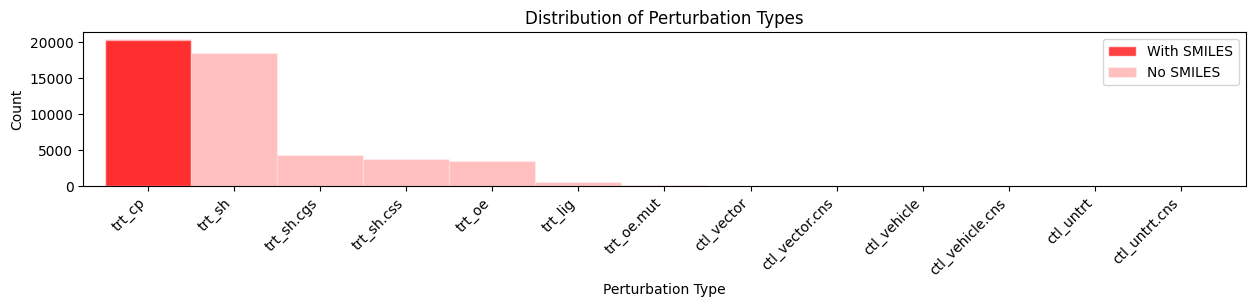

In [16]:
_, axes = plt.subplots(figsize=(15, 2))

df_per[df_per["canonical_smiles"] != "-666"]["pert_type"].value_counts().plot(
    kind="bar",
    ax=axes,
    width=1,
    color="red",
    edgecolor="white",
    title="Distribution of Perturbation Types",
    xlabel="Perturbation Type",
    ylabel="Count",
    alpha=0.75,
)
df_per["pert_type"].value_counts().plot(
    kind="bar",
    ax=axes,
    width=1,
    color="red",
    edgecolor="white",
    title="Distribution of Perturbation Types",
    xlabel="Perturbation Type",
    ylabel="Count",
    alpha=0.25,
)

plt.xticks(rotation=45, ha="right")
plt.legend(["With SMILES", "No SMILES"])
plt.show()


The trt_cp corresponding to small molecules are the only ones that have associated SMILES strings.  These will be used for modeling.

In [17]:
ids_with_smiles = df_per[df_per["canonical_smiles"] != "-666"]["pert_id"]

print(
    f"Perturbations with SMILES: {len(ids_with_smiles)} ({100 * len(ids_with_smiles) / df_per.shape[0]:.2f}%)"
)

Perturbations with SMILES: 20351 (39.61%)


**Mechanism of Action Data**

The mechanism of action data provides a classification label associated with different perturbations.

In [18]:
df_moa.head(3)

,pert_iname,clinical_phase,moa,target,disease_area,indication
0,"[sar9,met(o2)11]-substance-p",Preclinical,tachykinin antagonist,TACR1,NaN,NaN
1,A-1070722,Preclinical,glycogen synthase kinase inhibitor,GSK3A|GSK3B,NaN,NaN
2,A-1120,Preclinical,retinoid receptor ligand,RBP4,NaN,NaN


Add an MOA column to the Perturbation data for later classification.

In [19]:
df_per["moa"] = df_per["pert_iname"].map(
    df_moa.set_index("pert_iname")["moa"].to_dict()
)

**Signature Data**

The signature data provides details about the experiments performed with each row corresponding to a single column in the gene expression matrix.

* **sig_id**: the unique ID for this specific experiment signature. It's the primary key used to find this experiment's column in the main gene expression data file.

* **pert_id**: the ID for the perturbation (the drug) that was used. This ID can be used to look up the drug's chemical structure in the pert_info file.

* **pert_iname**: common, human-readable name of the drug. Here, it's tanespimycin.

* **pert_type**: what kind of perturbation was used.

    * **trt_cp**: Stands for "Treatment - Compound". This means a small molecule drug was used. 

    * **trt_sh**: Stands for "Treatment - shRNA". This means a gene was knocked down using a genetic tool. 

* **cell_id**: name of the cell line that was treated.

* **pert_dose / pert_idose**: dosage of the drug. pert_dose is the numerical value (e.g., 0.35), and pert_idose is the more descriptive string (e.g., 500 nM).

* **pert_time / pert_itime**: duration of the treatment. pert_time is the numerical value (e.g., 6), and pert_itime includes the unit (e.g., 6 h).

* **distil_id**: internal ID used by the Broad Institute for their data processing pipeline.

In [20]:
print(f"Signature Data Shape: {df_sig.shape}")
display(df_sig.sample(5))

Signature Data Shape: (473647, 12)


,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
423616,LJP002_MCF7_6H:K18,DMSO,DMSO,ctl_vehicle,MCF7,-666.0,-666,-666,6,h,6 h,LJP002_MCF7_6H_X1_F2B5_DUO52HI53LO:K18|LJP002_...
411759,KDD009_PC3_96H:TRCN0000039938:-666,TRCN0000039938,PRKAR1A,trt_sh,PC3,2.0,µL,2 µL,96,h,96 h,KDD009_PC3_96H_X1_B4_DUO52HI53LO:I02|KDD009_PC...
212565,DOS033_HT29_24H:BRD-K17817744-001-01-2:5.02,BRD-K17817744,BRD-K17817744,trt_cp,HT29,5.02,µM,5 µM,24,h,24 h,DOS033_HT29_24H_X1_F2B4_DUO52HI53LO:K19|DOS033...
336735,KDB007_PC3_96H:TRCN0000046537:-666,TRCN0000046537,TXNRD1,trt_sh,PC3,2.0,µL,2 µL,96,h,96 h,KDB007_PC3_96H_X2_B1_DUO52HI53LO:H03|KDB007_PC...
206512,DOS025_VCAP_6H:BRD-K87838816-001-01-6:4.97,BRD-K87838816,BRD-K87838816,trt_cp,VCAP,4.97,µM,5 µM,6,h,6 h,DOS025_VCAP_6H_X2_F1B6_DUO52HI53LO:I10|DOS025_...


In [21]:
sig_ids_with_smiles = df_sig[df_sig["pert_id"].isin(ids_with_smiles)]["sig_id"]

print(
    f"Experiments with SMILES: {len(sig_ids_with_smiles)} ({100 * len(sig_ids_with_smiles) / df_sig.shape[0]:.2f}%)"
)

Experiments with SMILES: 217572 (45.94%)


**Gene Data**

The gene data provides metadata about every gene measured in the LINCS L1000 project.

* **pr_gene_id**: the primary numerical ID for the gene (e.g., 21305909). This is the ID that will be used as the row index in the main expression data matrix

* **pr_gene_symbol**: the official, human-readable gene symbol that could be used in a publication or look up in a database.

* **pr_gene_title**: a longer, more descriptive name for the gene, often giving a hint about its function (e.g., RAP1 GTPase activating protein).

* **pr_is_lm**: an important flag that stands for "is landmark".

    * A value of 1 means this is one of the ~1000 "landmark" genes whose expression was directly measured by the L1000 assay.

    * A value of 0 means this gene's expression was inferred computationally from the landmark genes.

* **pr_is_bing**: This stands for "is Best INferred Gene".

    * A value of 1 indicates that this gene is part of a set of ~10,000 genes whose expression can be inferred with high confidence from the landmark genes.

In [22]:
print(f"Gene Data Shape: {df_gene.shape}")
display(df_gene.sample(5))

Gene Data Shape: (12328, 5)


,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
1488,2356,FPGS,folylpolyglutamate synthase,1,1
9616,79228,THOC6,THO complex 6,0,1
7516,92342,METTL18,methyltransferase like 18,0,1
1358,5567,PRKACB,protein kinase cAMP-activated catalytic subuni...,0,1
827,6241,RRM2,ribonucleotide reductase regulatory subunit M2,0,1


#### Filter the dataset

Because the data is so large, and a drugs effect can be different on different cell lines, simplify the problem and filter down to a more narrow group of experiments

In [23]:
# merge the perturbation and signature data
df_merged = pd.merge(
    df_per,
    df_sig.drop(columns=["pert_iname", "pert_type"]),
    left_on="pert_id",
    right_on="pert_id",
    how="left",
)
df_merged.shape

(473795, 18)

In [24]:
# select a single cell line
CELL_LINE = "MCF7"  # MCF7 is a well-characterized breast cancer cell line
PERT_TIME = 24  # 24 hours is a common treatment time in drug response studies
PERT_DOSE = "10.0"  # 10 uM is a common dose in drug response studies

# keep only chemical compounds
df_merged = df_merged[df_merged["pert_type"] == "trt_cp"].copy()

# keep only experiments with SMILES
df_merged = df_merged[df_merged["sig_id"].isin(sig_ids_with_smiles)].copy()

# select a single cell line
df_merged = df_merged[df_merged["cell_id"] == CELL_LINE].copy()

# filter down to a single treatment time
df_merged = df_merged[df_merged["pert_time"] == PERT_TIME].copy()

# filter down to a single dose
df_merged = df_merged[df_merged["pert_dose"] == PERT_DOSE].copy()

df_merged.shape

(7282, 18)

There are perturbations that have been run more than once at the same pert_time and pert_dose by design.  Average the results of these replicates to get a single, more robust gene expression signature for each unique treatment

In [25]:
df_merged["pert_id"].value_counts().iloc[:5]

pert_id
BRD-K81418486    60
BRD-A19500257    51
BRD-A19037878    51
BRD-A75409952    49
BRD-K18910433    12
Name: count, dtype: int64

In [26]:
df_merged[df_merged["pert_id"] == "BRD-K81418486"].iloc[:5]

,pert_id,pert_iname,pert_type,is_touchstone,inchi_key_prefix,inchi_key,canonical_smiles,pubchem_cid,moa,sig_id,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
171182,BRD-K81418486,vorinostat,trt_cp,1,WAEXFXRVDQXREF,WAEXFXRVDQXREF-UHFFFAOYSA-N,ONC(=O)CCCCCCC(=O)Nc1ccccc1,-666,HDAC inhibitor,ASG001_MCF7_24H:BRD-K81418486-001-24-4:10,MCF7,10.0,µM,10 µM,24.0,h,24 h,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:A05|ASG001_M...
171257,BRD-K81418486,vorinostat,trt_cp,1,WAEXFXRVDQXREF,WAEXFXRVDQXREF-UHFFFAOYSA-N,ONC(=O)CCCCCCC(=O)Nc1ccccc1,-666,HDAC inhibitor,CPC005_MCF7_24H:BRD-K81418486:10,MCF7,10.0,µM,10 µM,24.0,h,24 h,CPC005_MCF7_24H_X1_B4_DUO52HI53LO:B04|CPC005_M...
171313,BRD-K81418486,vorinostat,trt_cp,1,WAEXFXRVDQXREF,WAEXFXRVDQXREF-UHFFFAOYSA-N,ONC(=O)CCCCCCC(=O)Nc1ccccc1,-666,HDAC inhibitor,CPC006_MCF7_24H:BRD-K81418486:10,MCF7,10.0,µM,10 µM,24.0,h,24 h,CPC006_MCF7_24H_X1_B4_DUO52HI53LO:B04|CPC006_M...
171398,BRD-K81418486,vorinostat,trt_cp,1,WAEXFXRVDQXREF,WAEXFXRVDQXREF-UHFFFAOYSA-N,ONC(=O)CCCCCCC(=O)Nc1ccccc1,-666,HDAC inhibitor,CPC007_MCF7_24H:BRD-K81418486-001-21-0:10,MCF7,10.0,µM,10 µM,24.0,h,24 h,CPC007_MCF7_24H_X1_B5_DUO52HI53LO:H18|CPC007_M...
171399,BRD-K81418486,vorinostat,trt_cp,1,WAEXFXRVDQXREF,WAEXFXRVDQXREF-UHFFFAOYSA-N,ONC(=O)CCCCCCC(=O)Nc1ccccc1,-666,HDAC inhibitor,CPC007_MCF7_24H:BRD-K81418486:10,MCF7,10.0,µM,10 µM,24.0,h,24 h,CPC007_MCF7_24H_X1_B5_DUO52HI53LO:D02|CPC007_M...


In [27]:
replicate_groups = df_merged.groupby(["pert_id", "cell_id", "pert_dose", "pert_time"])[
    "sig_id"
].apply(list)
print(f"Found {len(replicate_groups)} unique drug treatments in the filtered set.")

Found 5741 unique drug treatments in the filtered set.


#### Load the Gene Matrix

* Each row represents a gene that is marked by a row id (rid) and can be mapped to a specific pr_gene_id in the `gene_info.txt` file.

* Each column represents a unique experiment that is marked by a col id (cid) that can be mapped to a specific sig_id in the `sig_info.txt` file.

* The values of the dataframe are normalized gene expression values indicating how much the genes expression changed in that experiment compared to its control.


In [28]:
col_metadata_df = parse_gctx(GCTX_DATA_PATH, col_meta_only=True)
all_sig_ids = col_metadata_df.index.tolist()
# Ensure that the number of signature IDs matches the number of signatures in the metadata
assert len(all_sig_ids) == df_sig.shape[0], (
    "Signature IDs do not match the number of signatures in the metadata."
)

/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


**Read in the experiments from our filtered set.**

In [29]:
filtered_sig_ids = set(df_merged["sig_id"].tolist())
filtered_sig_ids = list(filtered_sig_ids)

batch_gctoo = parse_gctx(GCTX_DATA_PATH, cid=filtered_sig_ids)
df_all = batch_gctoo.data_df

print(f"Data Shape: {df_all.shape}")
df_all.head(4)

/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


Data Shape: (12328, 7282)


cid,CPC005_MCF7_24H:BRD-A85280935-003-01-7:10,CPC005_MCF7_24H:BRD-A07824748-001-02-6:10,CPC005_MCF7_24H:BRD-K62929068-001-03-3:10,CPC005_MCF7_24H:BRD-K43405658-001-01-8:10,CPC005_MCF7_24H:BRD-K51223576-001-01-3:10,CPC005_MCF7_24H:BRD-A56675431-001-07-3:10,CPC005_MCF7_24H:BRD-K53979406-003-01-0:10,CPC005_MCF7_24H:BRD-K59419204-001-01-9:10,CPC005_MCF7_24H:BRD-A10969569-001-02-0:10,CPC005_MCF7_24H:BRD-K93188295-300-01-4:10,...,PCLB003_MCF7_24H:BRD-K18910433-001-26-7:10,PCLB003_MCF7_24H:BRD-K10466330-001-01-5:10,PCLB003_MCF7_24H:BRD-K64024097-001-02-8:10,PCLB003_MCF7_24H:BRD-K64106162-001-02-3:10,PCLB003_MCF7_24H:BRD-K16956545-001-01-0:10,PCLB003_MCF7_24H:BRD-K78431006-001-05-2:10,PCLB003_MCF7_24H:BRD-K63828191-003-23-0:10,PCLB003_MCF7_24H:BRD-K93754473-001-17-7:10,PCLB003_MCF7_24H:BRD-A52530684-003-01-7:10,PCLB003_MCF7_24H:BRD-A75409952-001-01-6:10
rid,,,,,,,,,,,,,,,,,,,,,
5720,-1.104279,-0.528817,0.165054,0.476758,0.235163,0.958309,0.439196,-0.308231,0.104582,0.289858,...,0.408504,0.383020,-0.646509,-0.240290,0.620854,-3.980333,1.931547,0.959719,0.125062,0.759589
466,-0.599829,1.063340,0.284834,0.727595,0.135943,0.846429,0.617767,0.952338,0.160561,0.387704,...,0.038143,-0.550278,0.730840,0.555458,-0.284504,-1.315245,0.619591,0.603761,-1.004396,-0.521165
6009,-0.095145,-0.051789,0.062587,-0.277198,-0.456056,0.625077,-0.583521,1.825451,0.370851,0.025000,...,0.741935,-0.148313,-0.065952,-0.751291,-0.376631,0.056077,1.136003,-1.322105,-1.071686,-0.377549
2309,-0.860346,-0.510285,0.488071,0.526337,-0.239833,0.269320,-0.199183,-0.765607,-0.058502,0.489323,...,0.766322,0.831062,-1.769938,0.501619,0.055693,-0.682625,1.080649,0.906715,-3.651138,0.760989


**Read in a control dataset with gene expression of DMSO**

DMSO (Dimethyl sulfoxide) is a common solvent used in biological experiments to dissolve chemical compounds that are not soluble in water. It serves as the negative control or vehicle control that will be used for visualization later on.

In [30]:
dmso_sig_ids = df_sig[df_sig["pert_iname"] == "DMSO"].sample(10000)["sig_id"]
dmso_sig_ids = set(dmso_sig_ids.tolist())
dmso_sig_ids = list(dmso_sig_ids)

dmso_gctoo = parse_gctx(GCTX_DATA_PATH, cid=dmso_sig_ids)
dmso_df = dmso_gctoo.data_df

print(f"Data Shape: {dmso_df.shape}")
dmso_df.head(4)

/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


Data Shape: (12328, 10000)


cid,CPC005_A375_6H:DMSO:-666,CPC005_A549_6H:DMSO:-666,CPC005_A549_24H:DMSO:-666,CPC001_HA1E_6H:DMSO:-666,CPC002_HA1E_6H:DMSO:-666,CPC003_HA1E_6H:DMSO:-666,CPC005_HA1E_6H:DMSO:-666,CPC001_HA1E_24H:DMSO:-666,CPC003_HA1E_24H:DMSO:-666,CPC004_HA1E_24H:DMSO:-666,...,PCLB002_A375_24H:DMSO:-666,PCLB002_HA1E_24H:DMSO:-666,PCLB002_HCC515_24H:DMSO:-666,PCLB002_HT29_24H:DMSO:-666,PCLB003_HA1E_24H:DMSO:-666,PCLB003_HCC515_24H:DMSO:-666,PCLB003_HEPG2_24H:DMSO:-666,PCLB003_HT29_24H:DMSO:-666,PCLB003_MCF7_24H:DMSO:-666,PCLB003_PC3_24H:DMSO:-666
rid,,,,,,,,,,,,,,,,,,,,,
5720,0.363173,0.706188,0.108998,0.427992,0.260583,0.654415,0.423885,0.209647,0.467368,0.471744,...,-0.434585,-0.282867,-0.116342,-0.489670,-0.800084,-0.663275,-0.774292,0.157644,-0.640806,-0.708406
466,0.313269,0.404338,0.126036,0.336631,0.204815,0.542310,0.360653,0.331452,0.144377,0.116612,...,0.248330,0.374824,0.184571,0.393877,-0.220115,-0.636154,-0.432666,0.174263,-0.309872,0.096245
6009,0.444590,-0.091623,-0.153613,0.246286,0.426484,0.133179,-0.257242,0.200606,0.151498,0.262971,...,-0.090928,-0.783168,0.591008,0.381087,-0.627477,-0.149718,1.174633,0.115687,-0.260007,1.304736
2309,-0.224244,-0.346145,-0.169471,-0.116414,0.150217,-0.614320,0.144656,-0.258776,0.468820,0.343986,...,-0.411373,0.022273,0.254374,-0.144712,0.141354,-0.589971,-0.229656,-0.382746,-0.722863,0.415391


In [31]:
DMSO_SIG_ID = "AML001_CD34_24H:A05"
DMSO_PERT_ID = "DMSO"

df_sig_dmso = df_sig[df_sig["sig_id"] == DMSO_SIG_ID]

dmso_sig_row = df_sig_dmso.drop(columns=["pert_iname", "pert_type"]).merge(
    df_per, on="pert_id", how="left"
)
dmso_sig_row

,sig_id,pert_id,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id,pert_iname,pert_type,is_touchstone,inchi_key_prefix,inchi_key,canonical_smiles,pubchem_cid,moa
0,AML001_CD34_24H:A05,DMSO,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:A05,DMSO,ctl_vehicle,1,IAZDPXIOMUYVGZ,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,CS(=O)C,-666,control vehicle


Add the dmso expression to df_all

In [32]:
df_all = pd.merge(
    df_all, dmso_df.mean(axis=1).rename(DMSO_SIG_ID), left_index=True, right_index=True
)

Also, add the DMSO row to the df_merged

In [33]:
df_merged = pd.concat([df_merged, dmso_sig_row], axis=0)

#### Average all Replicate Experiments

In [34]:
sig_to_pert_mapping = df_merged.set_index("sig_id")["pert_id"].to_dict()
df_averaged = df_all.T.groupby(sig_to_pert_mapping).mean()
df_averaged = df_averaged.T

df_averaged

,BRD-A00100033,BRD-A00267231,BRD-A00420644,BRD-A00474148,BRD-A00520476,BRD-A00546892,BRD-A00626522,BRD-A00758722,BRD-A00827783,BRD-A00993607,...,BRD-U51951544,BRD-U66370498,BRD-U68942961,BRD-U73238814,BRD-U82589721,BRD-U86922168,BRD-U88459701,BRD-U94846492,BRD-U97083655,DMSO
rid,,,,,,,,,,,,,,,,,,,,,
5720,0.826567,-0.568241,-2.189991,0.723845,-0.48505,0.217919,-0.55540,-1.264430,0.491229,0.112275,...,-1.33120,-0.045422,-2.841073,0.458586,-1.574413,-3.381999,0.130841,0.267506,0.331280,-0.063491
466,0.284471,0.703532,-1.198357,-0.820021,-0.92530,-0.103425,0.32280,-0.494967,0.465437,0.260624,...,-2.67475,-0.051166,-3.271909,0.744136,-1.011487,-0.525395,-0.857952,0.781003,0.622388,-0.065840
6009,-0.549101,0.357067,2.009591,-0.113706,-1.59015,-0.367488,-0.28730,0.466556,0.675874,-0.027216,...,-1.95965,0.042122,-0.231894,-0.291170,-0.020680,-0.311100,-0.676564,0.352920,0.284077,-0.004514
2309,-1.414383,-1.305485,2.530965,0.136478,-1.78720,0.285799,-0.02985,-0.001455,-1.215721,-0.088118,...,-4.38085,-0.963460,2.582773,0.101156,-1.336719,3.039191,0.261088,0.087820,-0.649788,-0.105785
387,0.298028,-0.370013,0.410572,-0.210709,-0.47810,-0.101240,0.43780,-0.099972,-0.004129,-0.588786,...,0.41375,-0.774725,-0.044668,-0.188228,0.754848,-0.368882,3.442191,0.252630,0.016547,0.071324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25960,-0.702823,0.389050,0.411424,-0.375076,0.57180,0.207068,-0.14505,0.373843,0.198210,0.499721,...,2.61460,1.613346,-0.272428,-0.980646,0.781393,0.193665,-1.372155,-0.219194,-0.114598,-0.014550
6376,-1.135657,0.010203,0.590206,-0.765630,-0.39100,-0.374216,0.10400,-0.246971,0.398666,-0.416996,...,0.95975,1.310484,0.017481,0.295986,-0.653096,-0.083449,0.203162,0.817905,-0.229802,-0.026285
11033,-1.214979,-0.113850,1.304059,0.163355,1.75985,0.486852,-0.78950,-0.738267,0.093434,-0.203176,...,1.12640,0.493943,-0.023583,-1.088944,1.204358,1.144818,-0.604002,0.679328,-0.367433,-0.027333


#### Perform Basic EDA on Gene Expression Data

**What is the overall distribution of the gene expression Z-scores?**

The data is described as "Level 5 Z-scores," which implies it has been normalized. We expect the distribution of all values in the matrix to look like a standard normal distribution.

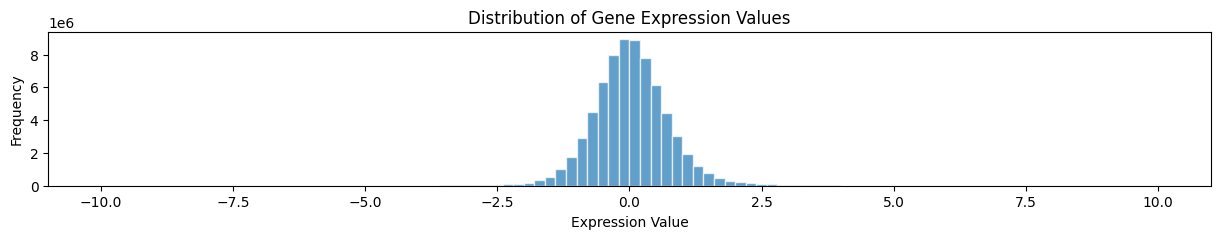

In [35]:
_, axes = plt.subplots(figsize=(15, 2))
plt.hist(df_averaged.values.flatten(), bins=100, edgecolor="white", alpha=0.7)
plt.title("Distribution of Gene Expression Values")
plt.xlabel("Expression Value")
plt.ylabel("Frequency");

**Which genes are the most "volatile" across all drug treatments?**

Determnine which genes are most commonly affected by drug perturbations, regardless of the specific drug.

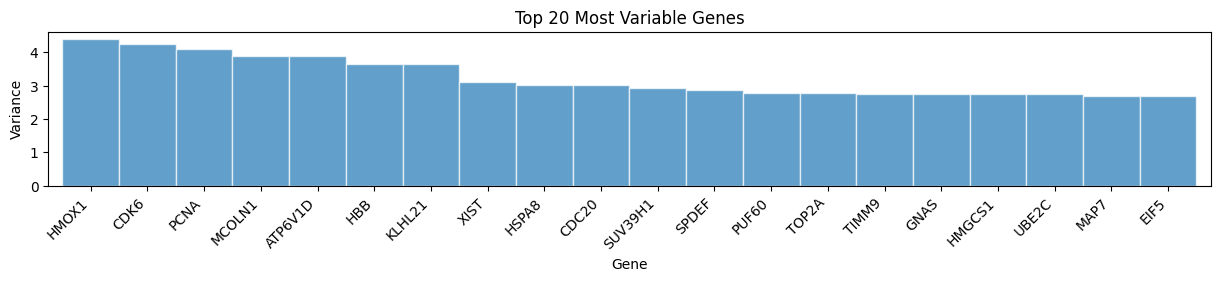

In [36]:
id_to_gene_mapping = df_gene.set_index("pr_gene_id")["pr_gene_symbol"].to_dict()
df_top_var_genes = df_averaged.var(axis=1).sort_values(ascending=False).head(20)

_, axes = plt.subplots(figsize=(15, 2))

df_top_var_genes.index = df_top_var_genes.index.astype(int).map(id_to_gene_mapping)
df_top_var_genes.plot(
    kind="bar",
    width=1,
    ax=axes,
    edgecolor="white",
    title="Top 20 Most Variable Genes",
    xlabel="Gene",
    ylabel="Variance",
    alpha=0.7,
)
plt.xticks(rotation=45, ha="right")
plt.show()

**How do different drugs affect a single gene?**

Check the range of effects on a specific biological pathway. For example, is a famous cancer gene like CDC20 (Cell Division Cycle 20 - crucial regulator of the cell cycle controling the progression of mitosis) up-regulated by many drugs, or only a specific few?

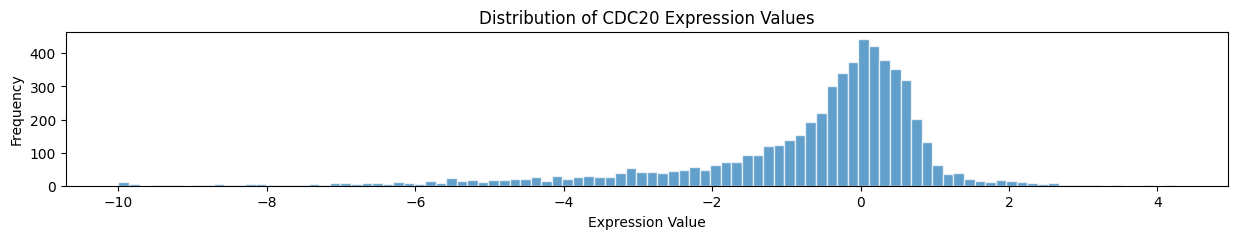

In [37]:
gene_to_id_mapping = {v: k for k, v in id_to_gene_mapping.items()}
cdc20_id = gene_to_id_mapping.get("CDC20")

_, axes = plt.subplots(figsize=(15, 2))
plt.hist(df_averaged.loc[str(cdc20_id)], bins=100, edgecolor="white", alpha=0.7)
plt.title("Distribution of CDC20 Expression Values")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")
plt.show()

**What is the distribution of MOA Labels?**

In [38]:
df_merged["moa"].fillna("Unknown", inplace=True)
df_merged["moa"].value_counts(normalize=True)

/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_77209/1762311794.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged["moa"].fillna("Unknown", inplace=True)


moa
Unknown                                  0.484553
HDAC inhibitor                           0.020321
dopamine receptor antagonist             0.014692
adrenergic receptor antagonist           0.013593
cyclooxygenase inhibitor                 0.013593
                                           ...   
guanylyl cyclase inhibitor               0.000137
protein tyrosine kinase activator        0.000137
cell cycle inhibitor                     0.000137
Aurora kinase inhibitor|JAK inhibitor    0.000137
control vehicle                          0.000137
Name: proportion, Length: 647, dtype: float64

In [39]:
df_merged["moa"].value_counts(normalize=True).iloc[:21].sum()

np.float64(0.6752711794590142)

There are 646 different mechanisms of action. This is too many for the classificaiton task we will perform.  For now, limit the number of classes to the top 20 classes (comprising 68% of the data), bucketing the other 626 classes as "Other".  In the future, this can be improved by grouping the categories into logical buckets.

In [40]:
top_moa_classes = df_merged["moa"].value_counts().iloc[:22].index.tolist()
df_merged["moa"] = df_merged["moa"].apply(
    lambda x: x if x in top_moa_classes else "Other"
)

Convert the MOA into an integer class

In [41]:
top_classes_minus_unknown = [
    top_class for top_class in top_moa_classes if top_class != "Unknown"
]
moa_to_int = {moa: i for i, moa in enumerate(top_classes_minus_unknown + ["Other"])}
moa_to_int["Unknown"] = -1
int_to_moa = {i: moa for moa, i in moa_to_int.items()}  # for later use in decoding

df_merged["moa_int"] = df_merged["moa"].map(moa_to_int)

df_merged[["pert_id", "moa", "moa_int"]].sample(5)

,pert_id,moa,moa_int
16479,BRD-A48430263,Other,21
7383,BRD-A19500257,HSP inhibitor,11
149658,BRD-K68538666,Other,21
88858,BRD-K32710582,Unknown,-1
26800,BRD-A79672927,acetylcholine receptor antagonist,5


**Observations**: 
* **Overall Gene Expression is Well-Behaved** The entire dataset follows a clean, standard normal distribution (a bell curve centered at zero). This confirms that the data has been Z-score normalized and is well-suited for machine learning, with no unusual biases. The tails of the distribution represent strong up- or down-regulation events.

* **A Core Set of Genes are Highly Responsive** Genes like HMOX1 (a stress response gene) and PCNA and CDK6 (cell cycle genes) are a few of the key players. These genes act as hubs for cellular response and are the most informative reporters of a cell's state after being treated with a drug.

* **Key Genes Like CDC20 are Common Targets** The distribution shows that while CD20 is often unperturbed (the peak at zero), a very common effect of the drugs in this dataset is to suppress its expression (the long tail on the left). This indicates that many different types of drugs converge on downregulating CDC20 to arrest the cell cycle.

---
### 5. Feature Engineering <a class="anchor" id="feature-engineering"></a>

In order to model the chemical composition of the drugs, we'll need to convert the SMILES strings into numerical vector. We'll use the Morgan Fingerprint to accomplish this goal. RDKits Morgan fingerprint generator creates a unique numerical identifier based on the [Morgan algorithm](https://pubs.acs.org/doi/abs/10.1021/c160017a018) ([blog](https://sharifsuliman.medium.com/understanding-morgan-f70186b172f6))

In [42]:
def smiles_to_fingerprint(smiles_string: str, n_bits: int = 2048) -> np.ndarray:
    """
    Converts a SMILES string to a Morgan fingerprint.

    Args:
        smiles_string (str): The SMILES representation of the molecule.
        n_bits (int, optional): The length of the fingerprint bit vector. Defaults to 2048.

    Returns:
        np.ndarray: A numpy array representing the Morgan fingerprint. If the input is invalid or restricted, returns an array of zeros.
    """
    if smiles_string == "restricted":
        return np.zeros(n_bits, dtype=np.float32)
    try:
        mol = Chem.MolFromSmiles(smiles_string)
        if mol is None:
            return np.zeros(n_bits, dtype=np.float32)
        fpgen = GetMorganGenerator(radius=2, fpSize=n_bits)
        fp = fpgen.GetFingerprint(mol)
        return np.array(fp, dtype=np.float32)
    except Exception:
        return np.zeros(n_bits, dtype=np.float32)


df_merged["fingerprint"] = df_merged["canonical_smiles"].apply(
    lambda x: smiles_to_fingerprint(x, n_bits=2048)
)
np.stack(df_merged["fingerprint"].values).shape

(7283, 2048)

Visualize the variety of the chemical fingerprints of the candidate drug compounds.

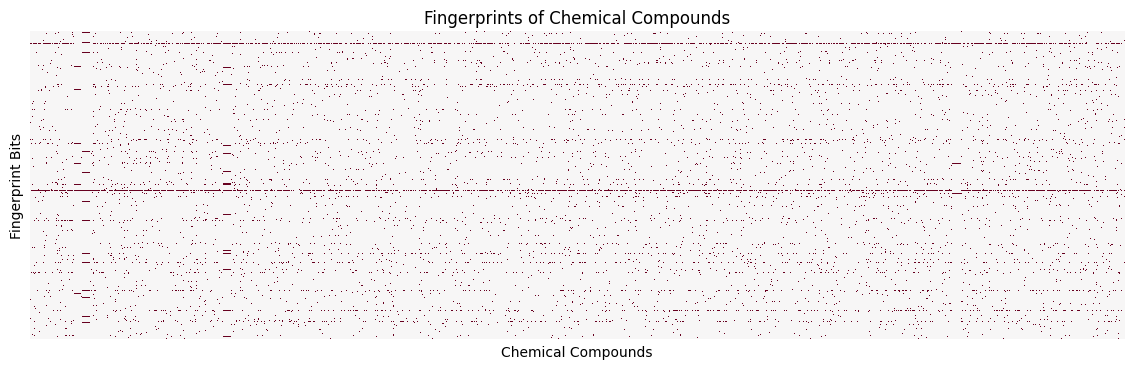

In [43]:
_, axes = plt.subplots(figsize=(15, 4))
sns.heatmap(
    np.stack(df_merged["fingerprint"].drop_duplicates().values).T,
    cmap="RdBu_r",
    xticklabels=False,
    yticklabels=False,
    cbar=False,
    square=True,
    vmin=-1,
    vmax=1,
    ax=axes,
)
plt.title("Fingerprints of Chemical Compounds")
plt.xlabel("Chemical Compounds")
plt.ylabel("Fingerprint Bits")
plt.show()

#### Build the Dataloader

In [44]:
BATCH_SIZE = 32
TRAIN_SPLIT = 0.8

df_meta = (
    df_merged[["pert_id", "moa_int", "fingerprint"]]
    .drop_duplicates(subset="pert_id")
    .set_index("pert_id")
)
np.random.seed(42)

# Ensure that the DMSO perturbation ID is in the validation set
train_pert_ids = np.random.choice(
    [pert_id for pert_id in df_averaged.columns if pert_id != DMSO_PERT_ID],
    size=int(TRAIN_SPLIT * df_averaged.shape[1]),
    replace=False,
)
train_pert_ids
val_pert_ids = np.setdiff1d(df_averaged.columns, train_pert_ids)

# flip the DataFrame to have perturbation IDs as rows
df_train = df_averaged.T.loc[train_pert_ids]
df_val = df_averaged.T.loc[val_pert_ids]

df_meta_train = df_meta.loc[df_train.index]
df_meta_val = df_meta.loc[df_val.index]

train_dataset = LincsDataset(df_train, df_meta_train)
val_dataset = LincsDataset(df_val, df_meta_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

assert all(df_train.index == df_meta_train.index), (
    "Training DataFrame index does not match train_map keys."
)
assert all(df_val.index == df_meta_val.index), (
    "Validation DataFrame index does not match val_map keys."
)

len(train_pert_ids), len(val_pert_ids)

(4593, 1149)

---
### 6. Train the Model <a class="anchor" id="model"></a>

#### Load Model Parameters

Load the configuration file that contains the model parameters for easy experiment tracking.  Initialize and visualize the model archetecture.

#### Train the Model

Train the model using weights and biases to track experiments with different parameters.

In [45]:
# read in training config
with open(
    os.path.join(ROOT, "config", "sweep.yaml"), "r"
) as file:
    sweep_config = yaml.safe_load(file)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sweep_id = wandb.sweep(sweep_config, project="drug_induced_gene_expression_prediction")

def train_with_sweep():
    with wandb.init() as run:
            
        config = wandb.config

        # # Initialize the CVAE model
        model = CVAE(
            expression_dim=df_averaged.shape[0],  # Number of genes
            num_classes=len(top_classes_minus_unknown)
            + 1,  # Number of MOA classes + 1 for "Other"
            condition_dim=df_meta["fingerprint"].iloc[0].shape[0],  # Fingerprint size
            hidden_dim=config["hidden_dim"],  # Hidden dimension for the encoder and decoder
            latent_dim=config["latent_dim"],  # Latent space dimension
            num_encoder_layers=config["num_encoder_layers"],  # Number of layers in the encoder
            encoder_dropout_rate=config["encoder_dropout"],  # Dropout rate for the encoder
            num_decoder_layers=config["num_decoder_layers"],  # Number of layers in the decoder
            condition_emb_dim=config["condition_emb_dim"],  # Embedding dimension for the condition (fingerprint)
            decoder_dropout_rate=config["decoder_dropout"],  # Dropout rate for the decoder
            num_molecular_emb_layers=config["num_molecular_emb_layers"], # Number of layers in the molecular embedding
        )
            
        num_epochs = config["num_epochs"]
        alpha = config["alpha"]  # Reconstruction loss weight
        gamma = config["gamma"]  # Classification loss weight
        beta = config["beta"]  # KL divergence weight

        sweep_name = run.sweep_id
        run_name = run.name
        run_id = run.name.split("-")[-1] 
        img_save_dir = f"{run_id}_{run_name}_cvae_model_{config['latent_dim']}latent_{config['hidden_dim']}hidden_{config['num_encoder_layers']}enclayers_{config['encoder_dropout']:.2f}do_{config['condition_emb_dim']}condembs_{config['learning_rate']:.2f}lr_{config['alpha']:.2f}a_{config['beta']:.2f}b_{config['gamma']:.2f}g_{config['num_molecular_emb_layers']}condlayers_{config['num_decoder_layers']}declayers"
        img_save_path = os.path.join(ROOT, "data", "hyperparameter_runs", sweep_name, img_save_dir)

        os.makedirs(img_save_path, exist_ok=True)

        optimizer = torch.optim.Adam(
            model.parameters(), lr=config["learning_rate"], weight_decay=1e-5
        )
        model = model.to(device)

        history: Dict[str, list] = {
            "train_loss": [],
            "val_loss": [],
            "train_recon": [],
            "val_recon": [],
            "train_kl": [],
            "val_kl": [],
            "train_class_loss": [],
            "val_class_loss": [],
        }

        best_val_loss = float("inf")  # Initialize best validation loss to infinity
        beta_ = beta  # Initialize beta for annealing if applicable
        for epoch in range(1, num_epochs + 1):
            if config["beta_anneal"]:
                beta_ = beta * ((epoch - 1) / num_epochs)
            # Training loop
            model, train_loss, train_recon, train_kl, train_class_loss = training_loop(
                model,
                train_loader,
                optimizer,
                num_epochs,
                alpha,
                beta_,
                gamma,
                device,
                epoch,
            )
            # Validation loop
            val_loss, val_recon, val_kl, val_class_loss = validation_loop(
                model, val_loader, device, alpha, beta_, epoch, num_epochs
            )
            
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)

            history["train_loss"].append(avg_train_loss)
            history["val_loss"].append(avg_val_loss)
            history["train_recon"].append(train_recon / len(train_loader))
            history["val_recon"].append(val_recon / len(val_loader))
            history["train_kl"].append(train_kl / len(train_loader))
            history["val_kl"].append(val_kl / len(val_loader))
            history["train_class_loss"].append(train_class_loss / len(train_loader))
            history["val_class_loss"].append(val_class_loss / len(val_loader))

            wandb.log(
                {
                    "Total Train Loss": avg_train_loss,
                    "Total Val Loss": avg_val_loss,
                    "Recon Train Loss": train_recon / len(train_loader),
                    "Recon Val Loss": val_recon / len(val_loader),
                    "KL Train": train_kl / len(train_loader),
                    "KL Val": val_kl / len(val_loader),
                    "Train Classification Loss": train_class_loss / len(train_loader),
                    "Val Classification Loss": val_class_loss / len(val_loader),
                    "Beta": beta_,
                    "Gamma": gamma,
                },
                step=epoch,
            )


        gsea_recon_error, gsea_gen_error = evaluate_recon_and_gen_gsea_for_pert(
            pert_id_to_test="BRD-A00993607",
            pert_id_control="DMSO",
            val_dataset=val_loader.dataset,
            df_gene=df_gene,
            img_save_path=img_save_path,
            model=model,
            device=device
        )

        train_corr, val_corr = get_recon_correlation(model, train_loader, val_loader, img_save_path)
        total_error_to_minimize = gsea_recon_error + gsea_gen_error + (1 - train_corr) + (1 - val_corr)
        wandb.log({
            "gsea_gen_error": gsea_gen_error,
            "gsea_recon_error": gsea_recon_error,
            "train_corr": train_corr,
            "val_corr": val_corr,
            "total_error_to_minimize": total_error_to_minimize
        })
        
        plot_training_history(history)
        plt.savefig(os.path.join(img_save_path, "training_history.png"))
        


Create sweep with ID: qauuiy3w
Sweep URL: https://wandb.ai/dantrainer01-none/drug_induced_gene_expression_prediction/sweeps/qauuiy3w


In [ ]:
# The 'count' argument specifies how many runs to execute
wandb.agent(sweep_id, function=train_with_sweep, count=100)

wandb: Agent Starting Run: vw8zsy0n with config:
wandb: 	alpha: 6187.731102176902
wandb: 	beta: 0.1817493226643745
wandb: 	beta_anneal: False
wandb: 	condition_emb_dim: 128
wandb: 	decoder_dropout: 0.08241010894380166
wandb: 	encoder_dropout: 0.15699500359167964
wandb: 	gamma: 0.09652188706668188
wandb: 	hidden_dim: 512
wandb: 	latent_dim: 32
wandb: 	learning_rate: 0.0001
wandb: 	num_decoder_layers: 1
wandb: 	num_encoder_layers: 1
wandb: 	num_epochs: 10
wandb: 	num_molecular_emb_layers: 0
wandb: Currently logged in as: dantrainer01 (dantrainer01-none) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 01 | Total Train Loss: 2772.2213 | Train Reconstruction Loss: 0.4449 | Train Classification Loss: 3.2740 | Train KL Divergence: 103.9395 | Beta: 0.1817 | Gamma: 0.0965: 100%|██████████| 144/144 [01:47<00:00,  1.34it/s]
Epoch 01 | Total Val Loss: 2156.8368 | Val Reconstruction Loss: 0.3456 | Val Classification Loss: 3.3015 | Val KL Divergence: 102.3486 | : 100%|██████████| 36/36 [00:01<00:00, 18.20it/s]
Epoch 02 | Total Train Loss: 2247.2662 | Train Reconstruction Loss: 0.3596 | Train Classification Loss: 3.3704 | Train KL Divergence: 118.5014 | Beta: 0.1817 | Gamma: 0.0965: 100%|██████████| 144/144 [01:47<00:00,  1.34it/s]
Epoch 02 | Total Val Loss: 1956.1923 | Val Reconstruction Loss: 0.3124 | Val Classification Loss: 3.3977 | Val KL Divergence: 126.3581 | : 100%|██████████| 36/36 [00:01<00:00, 19.40it/s]
Epoch 03 | Total Train Loss: 2100.1284 | Train Reconstruction Loss: 0.3355 | Train Classification Loss: 3.3794 | Train KL Divergence: 132.1406 | Beta: 0.1817 | Gamma: 0.0965: 1

Beta,▁▁▁▁▁▁▁▁▁▁
Gamma,▁▁▁▁▁▁▁▁▁▁
KL Train,▁▄▆▆▇▇▇▇▇█
KL Val,▁▅▇▆▅▅▆▆▆█
Recon Train Loss,█▄▄▃▂▂▂▂▁▁
Recon Val Loss,█▅▅▃▃▂▁▁▁▁
Total Train Loss,█▄▄▃▂▂▂▂▁▁
Total Val Loss,█▅▅▃▃▂▁▁▁▁
Train Classification Loss,▇██▇▅▅▃▃▂▁
Val Classification Loss,▇█▇▆▅▃▃▁▁▁
gsea_gen_error,▁


wandb: Agent Starting Run: prfc70x5 with config:
wandb: 	alpha: 5305.344868831655
wandb: 	beta: 0.584275467976033
wandb: 	beta_anneal: False
wandb: 	condition_emb_dim: 64
wandb: 	decoder_dropout: 0.20496334005491376
wandb: 	encoder_dropout: 0.2321702187271946
wandb: 	gamma: 0.01227922436131498
wandb: 	hidden_dim: 128
wandb: 	latent_dim: 256
wandb: 	learning_rate: 5e-05
wandb: 	num_decoder_layers: 1
wandb: 	num_encoder_layers: 1
wandb: 	num_epochs: 10
wandb: 	num_molecular_emb_layers: 1


Epoch 01 | Total Train Loss: 5098.4531 | Train Reconstruction Loss: 0.5969 | Train Classification Loss: 2.8656 | Train KL Divergence: 3306.0046 | Beta: 0.5843 | Gamma: 0.0123: 100%|██████████| 144/144 [00:14<00:00, 10.13it/s]
Epoch 01 | Total Val Loss: 2436.7800 | Val Reconstruction Loss: 0.4509 | Val Classification Loss: 2.7873 | Val KL Divergence: 76.2691 | : 100%|██████████| 36/36 [00:00<00:00, 66.31it/s]
Epoch 02 | Total Train Loss: 2649.3811 | Train Reconstruction Loss: 0.4882 | Train Classification Loss: 2.7148 | Train KL Divergence: 101.3447 | Beta: 0.5843 | Gamma: 0.0123: 100%|██████████| 144/144 [00:14<00:00, 10.28it/s]
Epoch 02 | Total Val Loss: 2286.0052 | Val Reconstruction Loss: 0.4230 | Val Classification Loss: 2.7249 | Val KL Divergence: 71.6767 | : 100%|██████████| 36/36 [00:00<00:00, 72.88it/s]
Epoch 03 | Total Train Loss: 2474.9269 | Train Reconstruction Loss: 0.4572 | Train Classification Loss: 2.6910 | Train KL Divergence: 84.7292 | Beta: 0.5843 | Gamma: 0.0123: 100

...

wandb: Agent Starting Run: 7egoff2a with config:
wandb: 	alpha: 5058.363198293184
wandb: 	beta: 0.15092006313854486
wandb: 	beta_anneal: False
wandb: 	condition_emb_dim: 128
wandb: 	decoder_dropout: 0.02564304768833431
wandb: 	encoder_dropout: 0.11716290685042872
wandb: 	gamma: 0.09429854562217292
wandb: 	hidden_dim: 128
wandb: 	latent_dim: 64
wandb: 	learning_rate: 0.0001
wandb: 	num_decoder_layers: 1
wandb: 	num_encoder_layers: 1
wandb: 	num_epochs: 10
wandb: 	num_molecular_emb_layers: 5


Epoch 01 | Total Train Loss: 43571.8404 | Train Reconstruction Loss: 0.4925 | Train Classification Loss: 3.3943 | Train KL Divergence: 272200.2604 | Beta: 0.1509 | Gamma: 0.0943: 100%|██████████| 144/144 [00:15<00:00,  9.27it/s]
Epoch 01 | Total Val Loss: 2090.8317 | Val Reconstruction Loss: 0.4096 | Val Classification Loss: 3.0832 | Val KL Divergence: 123.9902 | : 100%|██████████| 36/36 [00:00<00:00, 51.53it/s]
Epoch 02 | Total Train Loss: 2067.4080 | Train Reconstruction Loss: 0.4051 | Train Classification Loss: 2.9522 | Train KL Divergence: 118.6074 | Beta: 0.1509 | Gamma: 0.0943: 100%|██████████| 144/144 [00:15<00:00,  9.40it/s]
Epoch 02 | Total Val Loss: 1891.2730 | Val Reconstruction Loss: 0.3704 | Val Classification Loss: 2.8345 | Val KL Divergence: 116.2386 | : 100%|██████████| 36/36 [00:00<00:00, 52.18it/s]
Epoch 03 | Total Train Loss: 1938.3432 | Train Reconstruction Loss: 0.3794 | Train Classification Loss: 2.8595 | Train KL Divergence: 124.1310 | Beta: 0.1509 | Gamma: 0.094

Beta,▁▁▁▁▁▁▁▁▁▁
Gamma,▁▁▁▁▁▁▁▁▁▁
KL Train,█▁▁▁▁▁▁▁▁▁
KL Val,▃▁▄▃▄▆▆▇██
Recon Train Loss,█▅▄▃▃▂▂▂▁▁
Recon Val Loss,█▆▄▄▃▂▂▂▁▁
Total Train Loss,█▁▁▁▁▁▁▁▁▁
Total Val Loss,█▆▄▄▃▂▂▂▁▁
Train Classification Loss,█▄▃▂▂▂▂▂▁▁
Val Classification Loss,█▃▄▃▃▂▃▁▁▁
gsea_gen_error,▁


wandb: Agent Starting Run: hgo1tost with config:
wandb: 	alpha: 9662.486001072182
wandb: 	beta: 0.27564485058115296
wandb: 	beta_anneal: True
wandb: 	condition_emb_dim: 128
wandb: 	decoder_dropout: 0.07855666495107438
wandb: 	encoder_dropout: 0.1819770364344616
wandb: 	gamma: 0.08572293331930464
wandb: 	hidden_dim: 512
wandb: 	latent_dim: 32
wandb: 	learning_rate: 0.0001
wandb: 	num_decoder_layers: 1
wandb: 	num_encoder_layers: 0
wandb: 	num_epochs: 10
wandb: 	num_molecular_emb_layers: 0


Epoch 01 | Total Train Loss: 4150.9775 | Train Reconstruction Loss: 0.4296 | Train Classification Loss: 3.6884 | Train KL Divergence: 195.9045 | Beta: 0.0000 | Gamma: 0.0857: 100%|██████████| 144/144 [01:58<00:00,  1.21it/s]
Epoch 01 | Total Val Loss: 3292.8534 | Val Reconstruction Loss: 0.3408 | Val Classification Loss: 3.6540 | Val KL Divergence: 226.4364 | : 100%|██████████| 36/36 [00:02<00:00, 15.38it/s]
Epoch 02 | Total Train Loss: 3332.1804 | Train Reconstruction Loss: 0.3441 | Train Classification Loss: 4.0072 | Train KL Divergence: 250.7798 | Beta: 0.0276 | Gamma: 0.0857: 100%|██████████| 144/144 [02:28<00:00,  1.03s/it]
Epoch 02 | Total Val Loss: 2870.6252 | Val Reconstruction Loss: 0.2963 | Val Classification Loss: 3.7785 | Val KL Divergence: 270.5944 | : 100%|██████████| 36/36 [00:02<00:00, 15.33it/s]
Epoch 03 | Total Train Loss: 3066.9884 | Train Reconstruction Loss: 0.3158 | Train Classification Loss: 3.9668 | Train KL Divergence: 272.9440 | Beta: 0.0551 | Gamma: 0.0857: 1

#### Visualize the training curves

In [ ]:
img_save_dir = f"cvae_model_{config['latent_dim']}latent_{config['hidden_dim']}hidden_{config['num_encoder_layers']}enclayers_{config['encoder_dropout']}do_{config['condition_emb_dim']}condembs_{config['learning_rate']}lr_{config['alpha']}a_{config['beta']}b_{config['num_molecular_emb_layers']}condlayers_{config['num_decoder_layers']}declayers"
img_save_path = os.path.join(ROOT, "imgs", img_save_dir)

os.makedirs(img_save_path, exist_ok=True)

axes = plot_training_history(history)
plt.savefig(os.path.join(img_save_path, "training_history.png"))

NameError: name 'config' is not defined

**Observations**:
- ...

---
### 7. Gene Set Enrichment Analysis <a class="anchor" id="model"></a>

Gene Set Enrichment Analysis (GSEA) is a powerful computational method used to determine whether a defined set of genes, such as those in a specific biological pathway, show statistically significant, concordant differences between two biological states. Rather than looking at individual genes, GSEA works on a ranked list of all genes to identify pathways where the member genes are non-randomly clustered at the top (upregulated) or bottom (downregulated) of the list. This provides a systems-level view of the biological processes affected by a given perturbation.

#### Test the reconstruction ability

In [ ]:
# best_model_path = os.path.join(
#     ROOT, config["model_save_dir"], config["model_save_name"]
# )
# model.load_state_dict(torch.load(best_model_path))
model.eval()

CVAE(
  (molecular_embedding): MolecularEmbedding(
    (fc_initial): Linear(in_features=2048, out_features=128, bias=True)
    (fc_layers): ModuleList()
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (classification_head): ClassificationHead(
    (fc_initial): Linear(in_features=128, out_features=22, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (encoder): Encoder(
    (fc_initial): Linear(in_features=12456, out_features=256, bias=True)
    (fc_layers): ModuleList()
    (dropout): Dropout(p=0.1, inplace=False)
    (fc_mu): Linear(in_features=256, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=256, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (dropout): Dropout(p=0.3, inplace=False)
    (fc_initial): Linear(in_features=256, out_features=2048, bias=True)
    (fc_layers): ModuleList()
    (fc_final): Linear(in_features=2048, out_features=12328, bias=True)
  )
)

Bortezomib, a potent and specific proteasome inhibitor

In [ ]:
df_averaged.index

Index(['5720', '466', '6009', '2309', '387', '3553', '427', '5898', '23365',
       '6657',
       ...
       '2931', '63876', '51275', '158747', '283232', '25960', '6376', '11033',
       '54869', '60'],
      dtype='object', name='rid', length=12328)

In [ ]:
val_dataset.df_expression.index

Index(['BRD-A00474148', 'BRD-A00520476', 'BRD-A00546892', 'BRD-A00993607',
       'BRD-A01636364', 'BRD-A02759312', 'BRD-A04352665', 'BRD-A04392722',
       'BRD-A05831822', 'BRD-A06276885',
       ...
       'BRD-M16762496', 'BRD-M45038741', 'BRD-M61246020', 'BRD-M72681210',
       'BRD-M73371355', 'BRD-M86331534', 'BRD-U25771771', 'BRD-U37049823',
       'BRD-U68942961', 'DMSO'],
      dtype='object', length=1149)

In [ ]:
df_gene[["pr_gene_id", "pr_gene_symbol"]]

,pr_gene_id,pr_gene_symbol
0,780,DDR1
1,7849,PAX8
2,2978,GUCA1A
3,2049,EPHB3
4,2101,ESRRA
...,...,...
12323,4034,LRCH4
12324,399664,MEX3D
12325,54869,EPS8L1
12326,90379,DCAF15


In [ ]:
all_gene_names = (
    df_gene[["pr_gene_id", "pr_gene_symbol"]]
    .set_index("pr_gene_id")
    .loc[df_averaged.index.astype(int)]
    .values.squeeze()
    .tolist()
)
len(all_gene_names)

12328

In [ ]:
# def get_embs(condition, expression):
#     c_embs = model.molecular_embedding(condition)
#     x = torch.cat((expression, c_embs), dim=1)
#     embs = model.encoder(x)[0]
#     return embs.detach().numpy()


# embs_test = get_embs(condition_x, expression_x)
# embs_control = get_embs(condition_dmso, expression_dmso)

In [ ]:
# plt.hist(embs_control.flatten(), np.linspace(-3, 3, 100), alpha=0.5, label="DMSO")
# plt.hist(embs_test.flatten(), np.linspace(-3, 3, 100), alpha=0.5, label="Bortezomib")
# plt.title("Distribution of Gene Expression Values")
# plt.xlabel("Expression Value")
# plt.ylabel("Frequency")
# plt.legend()
# plt.show()

In [ ]:
# group_a_pert_ids = [
#     "BRD-K63089472",  # (Trichostatin A)
#     "BRD-A38749782",  # (Vorinostat)
#     "BRD-K53566850",  # (Panobinostat)
#     "BRD-K78481586",  # (Belinostat)
#     "BRD-A20131130",  # (Entinostat)
#     "BRD-K94304934",  # (Givinostat)
#     "BRD-A11135865",  # (Pracinostat)
#     "BRD-A00546892",  # (Quisinostat)
#     "BRD-K66956375",  # (Dacinostat)
#     "BRD-K38594532",  # (Abexinostat)
# ]
# group_b_pert_ids = [
#     "BRD-K45988865",  # (Wortmannin - PI3K inhibitor)
#     "BRD-A10188456",  # (Gefitinib - EGFR inhibitor)
#     "BRD-K71746704",  # (Lapatinib - EGFR/HER2 inhibitor)
#     "BRD-K02265150",  # (Dasatinib - Multi-kinase inhibitor)
#     "BRD-K76926998",  # (Sorafenib - Multi-kinase inhibitor)
#     "BRD-K18861610",  # (Vemurafenib - BRAF inhibitor)
#     "BRD-K13390322",  # (Trametinib - MEK inhibitor)
#     "BRD-A11968133",  # (Selumetinib - MEK inhibitor)
#     "BRD-A21481508",  # (Afatinib - EGFR/HER2 inhibitor)
#     "BRD-K88569143",  # (Axitinib - VEGFR inhibitor)
#     "BRD-K16472144",  # (Tofacitinib - JAK inhibitor)
#     "BRD-K41227865",  # (Ruxolitinib - JAK inhibitor)
# ]


In [ ]:
# def get_embeddings(pert_ids):
#     """Get embeddings for a list of perturbation IDs."""
#     embeddings = []
#     for pert_id in pert_ids:
#         condition, expression, _ = val_dataset.get_item_by_pert_id(pert_id)

#         c_embs = model.molecular_embedding(condition)
#         x = torch.cat((expression.unsqueeze(0), c_embs.unsqueeze(0)), dim=1)
#         embs = model.encoder(x)[0]
#         embeddings.append(embs.detach().numpy())

#     return np.array(embeddings)


# embs_group_a = get_embeddings(group_a_pert_ids).squeeze()
# embs_group_b = get_embeddings(group_b_pert_ids).squeeze()

In [ ]:
# from sklearn.decomposition import PCA
# import numpy as np

# import matplotlib.pyplot as plt

# # Assume `control_embeddings` and `drug_embeddings` are numpy arrays
# # containing your latent vectors for each group.
# all_embeddings = np.vstack([embs_group_a, embs_group_b])

# pca = PCA(n_components=2)
# projected_embeddings = pca.fit_transform(all_embeddings)

# # Separate the projected embeddings back into control and drug groups
# projected_controls = projected_embeddings[: len(embs_group_a)]
# projected_drugs = projected_embeddings[len(embs_group_a) :]

# plt.figure(figsize=(8, 8))

# # Plot the two groups of points
# plt.scatter(
#     projected_controls[:, 0],
#     projected_controls[:, 1],
#     alpha=0.5,
# )
# plt.scatter(
#     projected_drugs[:, 0],
#     projected_drugs[:, 1],
#     alpha=0.5,
# )

# # Optional: Draw the average effect vector
# control_center = projected_controls.mean(axis=0)
# drug_center = projected_drugs.mean(axis=0)
# # plt.arrow(control_center[0], control_center[1],
# #           drug_center[0] - control_center[0],
# #           drug_center[1] - control_center[1],
# #           head_width=0.2, width=0.05, color='black', length_includes_head=True)

# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.title("Latent Space Effect of Bortezomib")
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
val_loader.dataset.df_expression

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x327ccd6d0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 316d65d10, raw_cell="val_loader.dataset.df_expression" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/dantrainer/projects/cancer_research/notebooks/drug_induced_gene_expression_prediction_phaseII.ipynb#Y306sZmlsZQ%3D%3D>,),kwargs {}:


MailboxClosedError: 

rid,5720,466,6009,2309,387,3553,427,5898,23365,6657,...,2931,63876,51275,158747,283232,25960,6376,11033,54869,60
BRD-A00474148,0.723845,-0.820021,-0.113706,0.136478,-0.210709,-0.187563,0.154014,-1.126055,-0.762159,0.401845,...,0.080895,0.316904,0.402854,0.068809,-0.827525,-0.375076,-0.765630,0.163355,-0.359260,0.932355
BRD-A00520476,-0.485050,-0.925300,-1.590150,-1.787200,-0.478100,3.164050,1.030350,0.294450,0.056750,1.252800,...,1.831050,0.542200,-1.517350,1.368000,1.101500,0.571800,-0.391000,1.759850,0.041850,0.137600
BRD-A00546892,0.217919,-0.103425,-0.367488,0.285799,-0.101240,0.182152,0.353996,-0.739510,-1.052002,-0.073744,...,0.016535,-0.066087,0.110156,-0.171899,-0.236535,0.207068,-0.374216,0.486852,-0.127893,0.170410
BRD-A00993607,0.112275,0.260624,-0.027216,-0.088118,-0.588786,-0.323838,0.423648,-0.079968,0.094579,-0.585087,...,-0.510610,0.256077,0.495709,0.168894,0.545330,0.499721,-0.416996,-0.203176,0.042556,-0.600332
BRD-A01636364,-0.447928,0.185451,-0.285237,-0.326474,0.221008,0.338968,0.228538,-0.081907,0.963616,0.035250,...,0.016551,-0.313902,-0.418580,0.351363,0.275688,0.767861,-0.066677,-0.648614,-0.181613,0.086817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BRD-M86331534,-0.542471,-0.281938,-0.201238,2.108089,-1.420185,0.349359,0.471554,0.874947,-0.196320,0.581519,...,-0.391694,0.328867,0.120461,-0.207090,0.723866,0.470622,0.972289,1.242956,-0.914229,-0.182608
BRD-U25771771,-0.561556,-1.701386,-0.026190,-1.032070,-0.657888,1.187845,0.473458,-0.078489,-0.180403,0.911200,...,0.790823,0.227710,1.941458,1.172757,1.316243,-0.386218,1.791077,1.171628,-1.019690,-0.775151
BRD-U37049823,-2.825094,-0.203062,-0.366847,1.080122,-0.636220,0.878593,0.502933,1.602867,-0.164853,1.562752,...,-0.075155,-0.127811,0.218388,0.237322,0.965767,0.077761,0.559532,-0.469615,-0.316548,-0.356195
BRD-U68942961,-2.841073,-3.271909,-0.231894,2.582773,-0.044668,0.335093,0.558266,0.702609,1.600463,0.481217,...,0.054723,0.555105,0.047488,1.947896,1.105402,-0.272428,0.017481,-0.023583,0.768726,-0.870395


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x327ccd6d0>> (for post_run_cell), with arguments args (<ExecutionResult object at 316d64190, execution_count=65 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 316d65d10, raw_cell="val_loader.dataset.df_expression" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/dantrainer/projects/cancer_research/notebooks/drug_induced_gene_expression_prediction_phaseII.ipynb#Y306sZmlsZQ%3D%3D> result=rid                5720       466      6009      2309       387      3553  \
BRD-A00474148  0.723845 -0.820021 -0.113706  0.136478 -0.210709 -0.187563   
BRD-A00520476 -0.485050 -0.925300 -1.590150 -1.787200 -0.478100  3.164050   
BRD-A00546892  0.217919 -0.103425 -0.367488  0.285799 -0.101240  0.182152   
BRD-A00993607  0.112275  0.260624 -0.027216 -0.088118 -0.588786 -0.323838   
BRD-A01636364 -0.447928  0.185451 -0.285237 -0.326474

BrokenPipeError: [Errno 32] Broken pipe

In [ ]:
def get_control_and_test_profiles(pert_id_to_test, pert_id_control, dataset, df_gene):
    """
    Get the control and test profiles for a given perturbation ID.

    Args:
        pert_id_to_test (str): The perturbation ID to test.
        dataset (LincsDataset): The dataset containing the profiles.
        pert_id_control (str, optional): The control perturbation ID. Defaults to "DMSO".

    Returns:
        tuple: Condition and expression tensors for the test and control profiles.
    """

    condition_x, expression_x, _ = dataset.get_item_by_pert_id(pert_id_to_test)
    _, expression_dmso, _ = dataset.get_item_by_pert_id(
        pert_id_control
    )

    all_gene_names = (
        df_gene[["pr_gene_id", "pr_gene_symbol"]]
        .set_index("pr_gene_id")
        .loc[dataset.df_expression.T.index.astype(int)]
        .values.squeeze()
        .tolist()
    )

    condition_x = condition_x.unsqueeze(0).to(device)
    expression_x = expression_x.unsqueeze(0).to(device)

    control_x = expression_dmso.squeeze().detach().cpu().numpy()
    recon_x, _, _ = model(expression_x, condition_x)

    return expression_x, condition_x, recon_x, control_x, all_gene_names


def get_monte_carlo_generation(condition_x, model, device, num_samples=1000):
    all_generated_profiles = []
    for i in range(num_samples):
        torch.manual_seed(i)
        # Generate a new random latent vector
        z = torch.randn(condition_x.shape[0], model.latent_dim).to(device)
        c_embs = model.molecular_embedding(condition_x)

        z = torch.cat((z, c_embs), dim=1)

        generated_x = model.decoder(z)

        all_generated_profiles.append(generated_x.detach().cpu())
    
    mean_generated_x = torch.mean(torch.stack(all_generated_profiles), dim=0)

    return mean_generated_x


def calculate_log2_fold_change_from_control(recon_x, control_np, all_gene_names):
    """Calculate log2 fold change from the control profile.

    Args:
        recon_x (torch.Tensor): The reconstructed gene expression profile.
        control_np (np.ndarray): The control gene expression profile.
        all_gene_names (list): List of gene names corresponding to the expression profiles.
    """
    recon_x_np = recon_x.detach().cpu().numpy()
    log2_fold_change = recon_x_np - control_np

    ranked_gene_df = pd.DataFrame(
        {"gene_name": all_gene_names, "log2fc": log2_fold_change.squeeze()}
    )

    return ranked_gene_df.sort_values(by="log2fc", ascending=False)


def get_gsea_prerank(recon_x, control_np, all_gene_names):
    """Get the GSEA prerank DataFrame."""
    ranked_gene_df = calculate_log2_fold_change_from_control(
        recon_x, control_np, all_gene_names
    )
    prerank_obj = gseapy.prerank(
        rnk=ranked_gene_df, gene_sets="KEGG_2021_Human", seed=42
    )

    results_df = prerank_obj.res2d

    ranked_gene_df = ranked_gene_df.set_index("gene_name")
    significant_results = results_df[results_df["FDR q-val"] < 0.05]

    return significant_results


def evaluate_recon_and_gen_gsea_for_pert(pert_id_to_test, pert_id_control, val_dataset, df_gene, img_save_path, ):

    expression_x, condition_x, recon_x, control_x, all_gene_names = get_control_and_test_profiles(
        pert_id_to_test, pert_id_control, val_dataset, df_gene
    )

    mean_generated_x = get_monte_carlo_generation(condition_x, model, device)

    df_generated_results = get_gsea_prerank(mean_generated_x, control_x, all_gene_names)
    df_expression_results = get_gsea_prerank(expression_x, control_x, all_gene_names)
    df_reconstructed_results = get_gsea_prerank(recon_x, control_x, all_gene_names)

    df_results = pd.concat(
        [
            df_expression_results.set_index("Term")["ES"],
            df_reconstructed_results.set_index("Term")["ES"],
            df_generated_results.set_index("Term")["ES"],
        ],
        axis=1,
        keys=["Original Expression", "Reconstructed Expression", "Generated Expression"],
    )

    df_results = df_results.dropna(subset="Original Expression")
    df_results = df_results.fillna(0)

    gsea_recon_error = np.abs(df_results["Original Expression"] - df_results["Reconstructed Expression"]).sum().tolist()
    gsea_gen_error = np.abs(df_results["Original Expression"] - df_results["Generated Expression"]).sum().tolist()

    df_plot = pd.melt(
        df_results.dropna(subset="Original Expression").iloc[:10].reset_index(),
        id_vars=["Term"],
        var_name="Profile Type",
        value_name="Enrichment Score",
    )

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Create the bar plot
    ax = sns.barplot(
        data=df_plot,
        y="Term",
        x="Enrichment Score",
        hue="Profile Type",
        orient="h",
    )

    # Add a vertical line at zero for reference
    ax.axvline(0, color="black", lw=1)
    ax.grid(False)
    ax.set_title("GSEA Comparison for Bortezomib", fontsize=16)
    ax.set_xlabel("Normalized Enrichment Score (NES)", fontsize=12)
    ax.set_ylabel("")
    plt.legend(title="Profile Source")

    plt.savefig(os.path.join(img_save_path, "gsea_comparison.png"))

    return gsea_recon_error, gsea_gen_error


In [ ]:
def get_recon_correlation(img_save_path):
    train_expression = []
    train_reconstruction = []
    for (condition, expression, moa_label) in train_loader:
        recon_x, mu, log_var = model(expression, condition)
        train_reconstruction.append(recon_x.detach().cpu().numpy())
        train_expression.append(expression.detach().cpu().numpy())

    train_expression = np.vstack(train_expression)
    train_reconstruction = np.vstack(train_reconstruction)

    val_expression = []
    val_reconstruction = []
    for (condition, expression, moa_label) in val_loader:
        recon_x, mu, log_var = model(expression, condition)
        val_reconstruction.append(recon_x.detach().cpu().numpy())
        val_expression.append(expression.detach().cpu().numpy())
    val_expression = np.vstack(val_expression)
    val_reconstruction = np.vstack(val_reconstruction)
    

    val_corr = np.corrcoef(val_reconstruction.flatten(), val_expression.flatten())
    train_corr = np.corrcoef(train_reconstruction.flatten(), train_expression.flatten())

    _, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
    axes[0].hist(
        train_reconstruction.flatten() - train_expression.flatten(),
        bins=np.linspace(-3, 3, 20),
        alpha=0.5,
        label="Training Data"
    )
    axes[1].hist(
        val_reconstruction.flatten() - val_expression.flatten(),
        bins=np.linspace(-3, 3, 20),
        alpha=0.5,
        label="Validation Data",
    )
    axes[0].set_title("Distribution of Reconstruction Residuals (Training Data)\nCorrelation: {:.2f}".format(train_corr[0, 1]))
    axes[1].set_title("Distribution of Reconstruction Residuals (Validation Data)\nCorrelation: {:.2f}".format(val_corr[0, 1]))
    axes[0].set_xlabel("Reconstructed Residuals")
    axes[0].set_ylabel("Frequency")
    axes[1].set_xlabel("Reconstructed Residuals")
    plt.tight_layout()

    plt.savefig(os.path.join(img_save_path, "residuals.png"))

    return train_corr[0, 1], val_corr[0, 1]


In [ ]:
def train_cvae_model(config):

    # # Initialize the CVAE model
    model = CVAE(
        expression_dim=df_averaged.shape[0],  # Number of genes
        num_classes=len(top_classes_minus_unknown)
        + 1,  # Number of MOA classes + 1 for "Other"
        condition_dim=df_meta["fingerprint"].iloc[0].shape[0],  # Fingerprint size
        hidden_dim=config["hidden_dim"],  # Hidden dimension for the encoder and decoder
        latent_dim=config["latent_dim"],  # Latent space dimension
        num_encoder_layers=config["num_encoder_layers"],  # Number of layers in the encoder
        encoder_dropout_rate=config["encoder_dropout"],  # Dropout rate for the encoder
        num_decoder_layers=config["num_decoder_layers"],  # Number of layers in the decoder
        condition_emb_dim=config[
            "condition_emb_dim"
        ],  # Embedding dimension for the condition (fingerprint)
        decoder_dropout_rate=config["decoder_dropout"],  # Dropout rate for the decoder
        num_molecular_emb_layers=config[
            "num_molecular_emb_layers"
        ],  # Number of layers in the molecular embedding
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model, history = train_model(
        model,
        train_loader,
        val_loader,
        config=config,
        device=device,
    )

    img_save_dir = f"cvae_model_{config['latent_dim']}latent_{config['hidden_dim']}hidden_{config['num_encoder_layers']}enclayers_{config['encoder_dropout']}do_{config['condition_emb_dim']}condembs_{config['learning_rate']}lr_{config['alpha']}a_{config['beta']}b_{config['num_molecular_emb_layers']}condlayers_{config['num_decoder_layers']}declayers"
    img_save_path = os.path.join(ROOT, "imgs", img_save_dir)

    os.makedirs(img_save_path, exist_ok=True)

    plot_training_history(history)
    plt.savefig(os.path.join(img_save_path, "training_history.png"))

    return model, device, img_save_path

**Observations**: 

* GSEA results showed two clear, strong patterns:

  * Negative Enrichment: The Ribosome pathway was the most significant negatively enriched term. This means the VAE generated a profile where genes responsible for building ribosomes were strongly downregulated and clustered at the bottom of the ranked list.

  * Positive Enrichment: Pathways like DNA replication, Cell cycle, and multiple DNA repair pathways (Homologous recombination, Mismatch repair) were the most significant positively enriched terms. This means the VAE generated a profile where genes involved in these processes were strongly upregulated and clustered at the top of the ranked list.

* Bortezomib is a proteasome inhibitor. It blocks the cell's protein-recycling machinery. This causes a pile-up of old proteins, leading to a state of extreme cellular stress. The cell's primary defense mechanism is to shut down all non-essential production (stop making new proteins to conserve resources) and stop the cell cycle and try to fix the damage (stops dividing, starts DNA repair).  Both of which are consistent with what is displayed from the GSEA.

#### Get GSEA

#### Given only a new compound, can the VAE predict a feasible profile by sampling the latent space?

In [ ]:

def run_training_and_evaluation(config):
    """
    Run the training and evaluation of the CVAE model.
    
    Args:
        config (dict): Configuration dictionary containing model parameters and training settings.
    
    Returns:
        model (CVAE): The trained CVAE model.
        device (torch.device): The device on which the model is trained.
        img_save_path (str): Path to save the training history and evaluation plots.
    """
    model, device, img_save_path = train_cvae_model(config)


Epoch 01 | Total Train Loss: 284.0319 | Train Reconstruction Loss: 0.2774 | Train Classification Loss: 1.5526 | Train KL Divergence: 12.9420 | Beta: 0.5000 | Gamma: 0.1000:  51%|█████▏    | 74/144 [00:08<00:07,  9.08it/s]


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x327ccd6d0>> (for post_run_cell), with arguments args (<ExecutionResult object at 13b56ccd0, execution_count=60 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 13b56eb50, raw_cell="

model, device, img_save_path = train_cvae_model(.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/dantrainer/projects/cancer_research/notebooks/drug_induced_gene_expression_prediction_phaseII.ipynb#Y222sZmlsZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

# GSEA Plot

---
### 8. Summary

This project demonstrates ...


The primary findings include:

* ...

Next Steps:
* Investigate the effect of ...